# Equipment Calibration for HI Lab: Part 1 of 3

This notebook is the **Part 1 (equipment-calibration) stage** in a three-part HI analysis chain:

1. **Part 1 (this notebook):** characterize attenuation, gain-scale linearity, reflectometry constraints, and hardware bandpass responses.
2. **Part 2 (`temperature_calibration.ipynb`):** apply intensity calibration to obtain physically scaled spectra.
3. **Part 3 (`analysis.ipynb`):** perform astrophysical line analysis (velocity-frame conversion, profile interpretation, and science products).

The goal here is to produce physically defensible calibration products with uncertainties and explicit requirement traceability to the lab handouts.

## Requirement Traceability (Part 1 Scope)

Primary references:

- `src/ugradio/lab_bighorn/bighorn.tex`
- `src/ugradio/lab_bighorn/cal_intensity.tex`
- `src/ugradio/lab_bighorn/horn_signal_chain_test.tex`
- `src/ugradio/lab_bighorn/coords.tex`

| ID | Requirement / theory item | Where addressed | Status |
|---|---|---|---|
| `R-SC-001` | Receiver chain gain/loss accounting (horn -> SDR) | Signal-chain gain sections + bench chain metrics | Covered |
| `R-SC-002` | Coax attenuation per meter near 1420 MHz | Shared-slope SDR + meter linear fits | Covered |
| `R-SC-003` | Unknown cable length inference with uncertainty | Inversion + Jacobian propagation | Covered |
| `R-SC-004` | SDR gain-scale linearity and clipping guardrails | Fixed-gain sweep diagnostics | Covered |
| `R-SC-005` | RTL2832U FIR + residual summing-filter response | FIR + cold_ref whitening + constrained optimization | Covered |
| `R-SC-006` | Reflectometry timing ambiguity and branch selection | Square-wave branch resolution and velocity-factor check | Covered |
| `R-SC-007` | VSWR/reflection-coefficient requirement awareness | Explicitly documented as a measurement gap | Covered with limitation |
| `R-CAL-001` | `cal_intensity.tex` cool-method calibration theory | Full derivation block below | Covered |
| `R-CAL-002` | First-order error propagation (sum/product/Jacobian) | Uncertainty derivation + implementation mapping | Covered |
| `R-COORD-001` | Coordinate transforms for sky/LSR analysis | Deferred to `analysis.ipynb` (Part 3), linked in handoff | Deferred intentionally |

## 1) Physical Setup and Modeling Assumptions

This section defines constants and assumptions used throughout Part 1.

### Hardware and measurement assumptions

- Coax attenuation over the sampled length range is modeled as first-order linear in dB: `y(L)=B-\alpha L`.
- Splitter and fixed attenuator losses are treated as additive constants in dB (intercept shifts), not slope changes.
- The 12-ft lead-in (`3.6576 m`) is subtracted only at the final unknown-cable estimate stage.

### Statistical assumptions

- Fit-parameter uncertainty combines OLS covariance with Monte Carlo perturbation from cable-length read uncertainty.
- Length inversion uncertainty is propagated by first-order Jacobian rules (consistent with `cal_intensity.tex`).

### Scope boundary

This notebook calibrates hardware terms used downstream; it does not perform sky-coordinate transforms or final astrophysical HI interpretation.

### Measurement-resolution inputs used for uncertainty propagation

- Ruler smallest division: `0.2 mm` -> per-read standard uncertainty proxy `sigma_L_read = 0.1 mm`.
- Power-meter smallest division: `0.2 dBm` -> per-read standard uncertainty proxy `sigma_P_read = 0.1 dB`.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ugradiolab import Spectrum

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['figure.dpi'] = 300

DATA_ROOT = Path('data/lab02') if Path('data/lab02').exists() else Path('../../data/lab02')
NB_DIR = Path('labs/02') if Path('labs/02').exists() else Path('.')
CACHE_DIR = NB_DIR / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

UNKNOWN_LEAD_LENGTH_M = 12 * 0.3048          # 12 ft fixed lead-in = 3.6576 m

# Meter-rule length uncertainty policy
METER_RULE_DIVISION_M = 0.2e-3               # 0.2 mm smallest division
SIGMA_LENGTH_READ_M = METER_RULE_DIVISION_M / 2.0   # +/- 0.1 mm per read
SIGMA_CAL_LENGTH_M = SIGMA_LENGTH_READ_M            # apply to calibration cable lengths
SIGMA_LEAD_LENGTH_M = SIGMA_LENGTH_READ_M           # apply to fixed lead-in subtraction

# Monte-Carlo settings for propagating sigma_L into fit covariance
LENGTH_UNCERTAINTY_MC_SAMPLES = 4000
LENGTH_UNCERTAINTY_MC_SEED = 121


# Diagnostics-first screening policy
OUTLIER_Z_THRESHOLD = 3.5
MIN_POINTS_AFTER_SCREEN = 6
INFLUENCE_ALPHA_DELTA_THRESHOLD = 0.6   # dB/m leave-one-out delta-alpha trigger

# Primary-estimate rule
PRIMARY_RULE_REQUIRE_POSITIVE_ALPHA_CI95 = True
PRIMARY_RULE_MAX_RELATIVE_CI95_WIDTH = 1.0   # choose meter-primary if SDR CI95 width > 100% of |estimate|

# ── ZFSC-2-372-S+ splitter measured insertion losses ─────────────────────────
# Measured at two frequencies; linearly interpolated to SIGGEN_FREQ_MHZ.
SIGGEN_FREQ_MHZ          = 1420.405751768   # 21-cm line (from manifest)

SPLITTER_S1_DB_1200MHZ   = 3.39   # S -> Port 1 (power meter branch) at 1200 MHz
SPLITTER_S1_DB_1600MHZ   = 3.36   # S -> Port 1                            at 1600 MHz
SPLITTER_S2_DB_1200MHZ   = 3.37   # S -> Port 2 (SDR branch)               at 1200 MHz
SPLITTER_S2_DB_1600MHZ   = 3.33   # S -> Port 2                            at 1600 MHz

_t = (SIGGEN_FREQ_MHZ - 1200.0) / (1600.0 - 1200.0)
SPLITTER_S1_DB = SPLITTER_S1_DB_1200MHZ + _t * (SPLITTER_S1_DB_1600MHZ - SPLITTER_S1_DB_1200MHZ)
SPLITTER_S2_DB = SPLITTER_S2_DB_1200MHZ + _t * (SPLITTER_S2_DB_1600MHZ - SPLITTER_S2_DB_1200MHZ)
del _t

ATTENUATOR_SDR_DB   = 3.0             # fixed 3 dB attenuator on port 2 -> SDR
PORT2_CABLE_LEN_M   = 6 * 0.3048      # 6-ft cable between port 2 and attenuator

print(f'DATA_ROOT         : {DATA_ROOT.resolve()}')
print(f'Lead-in length    : {UNKNOWN_LEAD_LENGTH_M:.4f} m ({UNKNOWN_LEAD_LENGTH_M/0.3048:.1f} ft)')
print(f'Splitter S->Port1 @ {SIGGEN_FREQ_MHZ:.3f} MHz : {SPLITTER_S1_DB:.4f} dB')
print(f'Splitter S->Port2 @ {SIGGEN_FREQ_MHZ:.3f} MHz : {SPLITTER_S2_DB:.4f} dB')
print(f'SDR attenuator                            : {ATTENUATOR_SDR_DB:.1f} dB')
print(f'Port-2 cable length                       : {PORT2_CABLE_LEN_M:.4f} m ({PORT2_CABLE_LEN_M/0.3048:.0f} ft)')
print(f'Meter-rule division                       : {METER_RULE_DIVISION_M*1e3:.1f} mm')
print(f'Length read sigma                         : {SIGMA_LENGTH_READ_M*1e3:.3f} mm')



# ── Receiver component parameters for signal-chain / Friis analysis ──────────
ZKL_GAIN_TYP_DB_1420  = 26.8   # Mini-Circuits ZKL-33ULN-S+ typical gain @ 1.4 GHz (datasheet)
ZKL_NF_DB_1420        = 0.75   # Mini-Circuits ZKL-33ULN-S+ noise figure @ 1.4 GHz (datasheet)
REACTEL_IL_ASSUMED_DB = 2.0    # Reactel bandpass filter insertion loss (assumed)
KL_BPF_IL_DB          = 1.0    # K&L Microwave 5B120-1380/160-0 assumed insertion loss
WIDEBAND_AMP_GAIN_DB  = 20.0   # Wideband RF amp gain
WIDEBAND_AMP_NF_DB    = 3.0    # Wideband amp noise figure (assumed)
NARROWBAND_AMP_GAIN_DB = 20.0  # Narrowband RF amp gain
NARROWBAND_AMP_NF_DB   = 3.0   # Narrowband amp noise figure (assumed)
CABLE_PRIOR_M         = 35.0   # Prior estimate of roof-to-lab cable run (m)

# ── Bench-probed block-level gain values (Cell 7c, 2026-03-07, +20 dBm siggen) ──
BENCH_BASELINE_LOSS_DB        = 4.3   # two 6-ft reference cables
BENCH_UNKNOWN_CABLE_LOSS_DB   = 29.3  # unknown cable incremental loss
BENCH_ROOF_CHAIN_NET_GAIN_DB  = 31.5  # ZKL#1 + Reactel + ZKL#2 + ZKL#3 (may include compression)
BENCH_KL_FILTER_LOSS_DB       = 20.3  # K&L BPF insertion loss
BENCH_LAB_AMPS_NET_GAIN_DB    = 12.1  # wideband + narrowband amps combined


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


DATA_ROOT         : /Users/junruiting/GitHub/ay-121/data/lab02
Lead-in length    : 3.6576 m (12.0 ft)
Splitter S->Port1 @ 1420.406 MHz : 3.3735 dB
Splitter S->Port2 @ 1420.406 MHz : 3.3480 dB
SDR attenuator                            : 3.0 dB
Port-2 cable length                       : 1.8288 m (6 ft)
Meter-rule division                       : 0.2 mm
Length read sigma                         : 0.100 mm


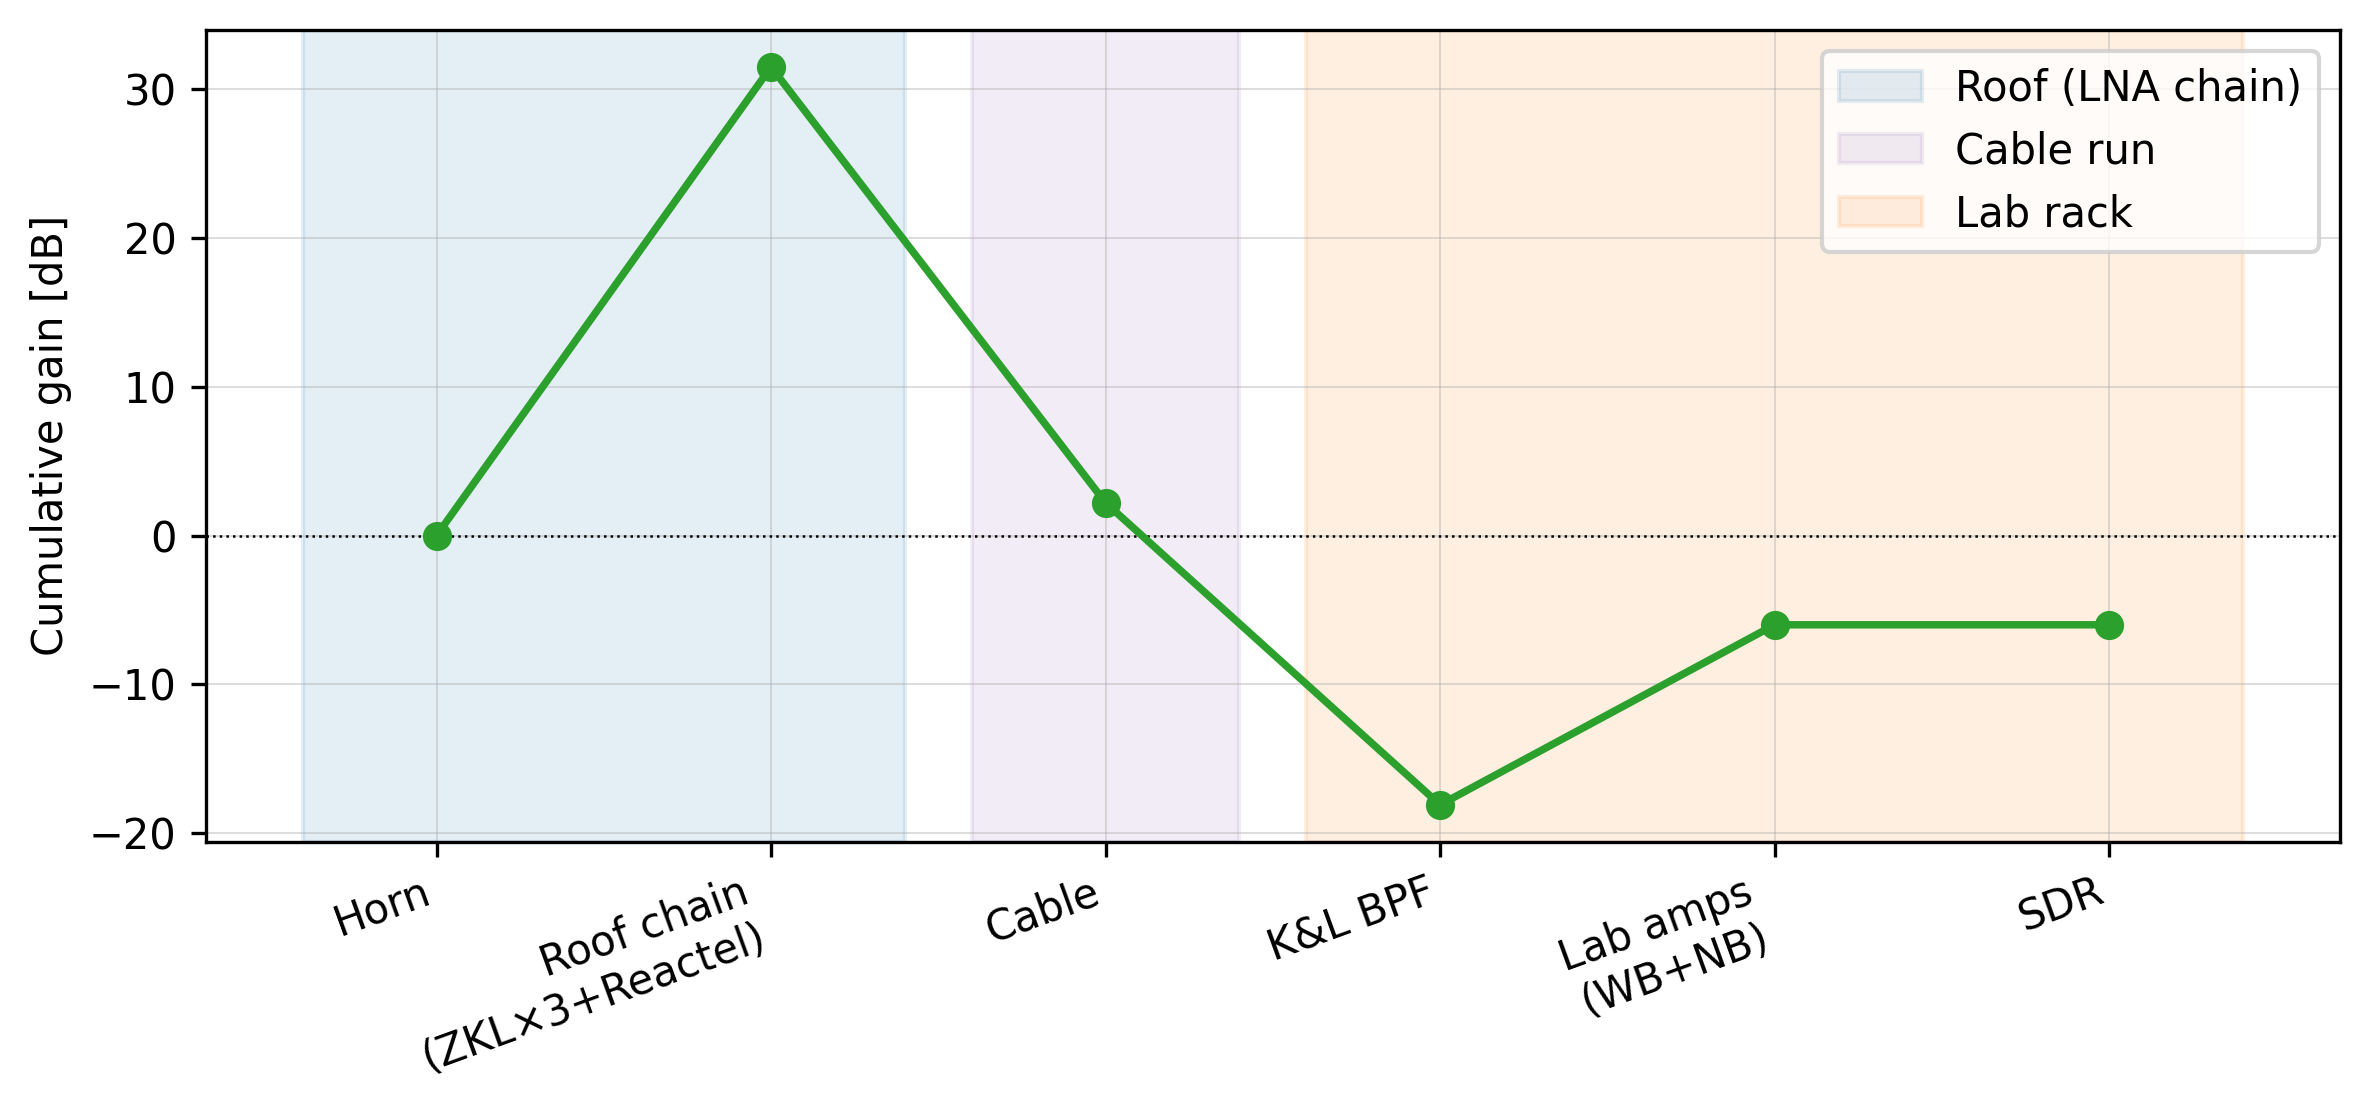

Net gain Horn → SDR : -6.0 dB


In [2]:
# ── Signal-chain measured cumulative gain ────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# Blocks: (label, gain_db, region)
# Gain values from bench probing (Cell 7c, 2026-03-07).
blocks = [
    ('Horn',                         0,                              'roof'),
    ('Roof chain\n(ZKL×3+Reactel)',  BENCH_ROOF_CHAIN_NET_GAIN_DB,  'roof'),
    ('Cable',                       -BENCH_UNKNOWN_CABLE_LOSS_DB,   'cable'),
    ('K&L BPF',                     -BENCH_KL_FILTER_LOSS_DB,       'lab'),
    ('Lab amps\n(WB+NB)',            BENCH_LAB_AMPS_NET_GAIN_DB,    'lab'),
    ('SDR',                          0,                             'lab'),
]

# Cumulative gain
G_cum_db = [0.0]
for _, g_db, _ in blocks[1:]:
    G_cum_db.append(G_cum_db[-1] + g_db)

x       = np.arange(len(blocks))
labels  = [b[0] for b in blocks]
regions = [b[2] for b in blocks]

region_color = {'roof': 'C0', 'cable': 'C4', 'lab': 'C1'}
region_label = {'roof': 'Roof (LNA chain)', 'cable': 'Cable run', 'lab': 'Lab rack'}

fig, ax = plt.subplots(figsize=(8, 4))

# Region shading
prev_reg = regions[0]; seg_start = 0; _seen_lbl = set()
for j in range(1, len(regions) + 1):
    cur_reg = regions[j] if j < len(regions) else None
    if cur_reg != prev_reg or j == len(regions):
        lbl = region_label[prev_reg] if prev_reg not in _seen_lbl else '_nolegend_'
        _seen_lbl.add(prev_reg)
        ax.axvspan(seg_start - 0.4, j - 1 + 0.4,
                   color=region_color[prev_reg], alpha=0.12, label=lbl)
        seg_start = j; prev_reg = cur_reg

ax.plot(x, G_cum_db, 'o-', color='C2', lw=1.8, zorder=3)

ax.axhline(0, color='k', lw=0.6, ls=':')
ax.set_ylabel('Cumulative gain [dB]')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.grid(True, lw=0.4, alpha=0.5)
ax.legend(loc='upper right')

fig.tight_layout(rect=[0, 0.05, 1, 1])
_nb_dir = Path('labs/02') if Path('labs/02').exists() else Path('.')
plt.savefig(_nb_dir / 'report' / 'figures' / 'signal_chain.pdf', bbox_inches='tight')
plt.show()

print(f'Net gain Horn → SDR : {G_cum_db[-1]:.1f} dB')


## 2) Bench-Measured Signal-Chain Gain Context

The cumulative-gain plot uses **bench-probed block values** (dated 2026-03-07) to summarize end-to-end gain/loss structure from horn-side chain to SDR input.

Interpretation focus:

- verify that measured gain budget is plausible for ADC usage,
- identify anomalous losses (notably unexpectedly high K&L insertion loss),
- establish physically consistent priors for later calibration and safety checks.

## 3) Analysis Operators and Theory-to-Code Mapping

Helper functions below implement the mathematical operators used in this notebook.

### Model equations implemented

- Shared-slope SDR attenuation model:
  $$
  y_{1420}(L)=B_{1420}-\alpha L,\qquad y_{1421}(L)=B_{1421}-\alpha L
  $$
- Meter branch model:
  $$
  y_{\mathrm{meter}}(L)=B_{\mathrm{meter}}-\alpha_{\mathrm{meter}}L
  $$
- Unknown-length inversion:
  $$
  L_i=\frac{B_i-y_i}{\alpha},\quad i\in\{1420,1421\}
  $$

### Error-propagation operators implemented

- `propagate_length_sigma(...)` for first-order Jacobian propagation,
- shared-fit covariance use for coupled parameters `[B_{1420}, B_{1421}, \alpha]`.

In [3]:
# ── Manifest loading ──────────────────────────────────────────────────────────

def _find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'ugradiolab').exists():
            return p
    raise RuntimeError('Cannot locate repository root.')


def load_manifest(path: Path) -> pd.DataFrame:
    """Load manifest CSV; resolve lo1420_path/lo1421_path to absolute Path objects."""
    df = pd.read_csv(path)
    root = _find_repo_root()
    for col in ('lo1420_path', 'lo1421_path'):
        df[col] = df[col].apply(lambda s: (root / s).resolve())
    return df


def load_spectra_from_manifest(df: pd.DataFrame) -> dict:
    """Load (Spectrum_1420, Spectrum_1421) pairs keyed by set_id from raw Record files."""
    pairs = {}
    for _, row in df.iterrows():
        s0 = Spectrum.from_data(row['lo1420_path'])
        s1 = Spectrum.from_data(row['lo1421_path'])
        pairs[int(row['set_id'])] = (s0, s1)
    return pairs


def validate_manifest(df: pd.DataFrame, *, require_cable_length: bool, label: str) -> pd.DataFrame:
    """Validate required manifest columns/numeric fields before normalization."""
    required = [
        'set_id', 'lo1420_path', 'lo1421_path',
        'lo1420_total_power', 'lo1421_total_power',
        'power_meter_dbm', 'siggen_freq_mhz', 'siggen_amp_dbm',
    ]
    if require_cable_length:
        required.append('cable_length_m')

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f'{label}: missing required columns {missing}')

    out = df.copy()
    numeric_cols = [
        'lo1420_total_power', 'lo1421_total_power',
        'power_meter_dbm', 'siggen_freq_mhz', 'siggen_amp_dbm',
    ]
    if require_cable_length:
        numeric_cols.append('cable_length_m')

    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors='coerce')

    bad_rows = out.index[out[numeric_cols].isna().any(axis=1)].tolist()
    if bad_rows:
        raise ValueError(f'{label}: non-finite required numeric fields in rows {bad_rows}')

    if (out['lo1420_total_power'] <= 0).any() or (out['lo1421_total_power'] <= 0).any():
        raise ValueError(f'{label}: total_power must be positive for log-normalization')

    if require_cable_length and (out['cable_length_m'] < 0).any():
        raise ValueError(f'{label}: cable_length_m must be non-negative')

    return out


# ── Normalisation ─────────────────────────────────────────────────────────────

def to_normalised_db(total_power: float, siggen_amp_dbm: float) -> float:
    """Normalised dB proxy: 10*log10(total_power) - siggen_amp_dbm."""
    return 10.0 * np.log10(float(total_power)) - float(siggen_amp_dbm)


# ── Model fit utilities ───────────────────────────────────────────────────────

def _aic_bic(rss: float, n_obs: int, n_params: int) -> tuple:
    if rss <= 0 or n_obs <= n_params:
        return np.nan, np.nan
    aic = n_obs * np.log(rss / n_obs) + 2 * n_params
    bic = n_obs * np.log(rss / n_obs) + n_params * np.log(n_obs)
    return float(aic), float(bic)


def _mc_cov_shared_length(L: np.ndarray,
                          y0: np.ndarray,
                          y1: np.ndarray,
                          sigma_L: float,
                          n_mc: int,
                          seed: int) -> np.ndarray:
    """Monte-Carlo parameter covariance from uncertainty in cable lengths only."""
    L = np.asarray(L, float)
    y0 = np.asarray(y0, float)
    y1 = np.asarray(y1, float)
    if not np.isfinite(sigma_L) or sigma_L <= 0 or n_mc < 4:
        return np.zeros((3, 3), dtype=float)

    rng = np.random.default_rng(seed)
    betas = np.full((int(n_mc), 3), np.nan, dtype=float)

    for k in range(int(n_mc)):
        Lj = L + rng.normal(0.0, sigma_L, size=L.size)
        if np.unique(np.round(Lj, 9)).size < 2:
            continue

        n = Lj.size
        y = np.concatenate([y0, y1])
        X = np.zeros((2 * n, 3), dtype=float)
        X[:n, 0] = 1.0
        X[:n, 2] = -Lj
        X[n:, 1] = 1.0
        X[n:, 2] = -Lj
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        betas[k, :] = beta

    valid = betas[np.isfinite(betas).all(axis=1)]
    if valid.shape[0] < 4:
        return np.zeros((3, 3), dtype=float)
    return np.asarray(np.cov(valid, rowvar=False, ddof=1), dtype=float)


def _mc_cov_single_length(L: np.ndarray,
                          y: np.ndarray,
                          sigma_L: float,
                          n_mc: int,
                          seed: int) -> np.ndarray:
    """Monte-Carlo parameter covariance from uncertainty in cable lengths only."""
    L = np.asarray(L, float)
    y = np.asarray(y, float)
    if not np.isfinite(sigma_L) or sigma_L <= 0 or n_mc < 4:
        return np.zeros((2, 2), dtype=float)

    rng = np.random.default_rng(seed)
    betas = np.full((int(n_mc), 2), np.nan, dtype=float)

    for k in range(int(n_mc)):
        Lj = L + rng.normal(0.0, sigma_L, size=L.size)
        if np.unique(np.round(Lj, 9)).size < 2:
            continue

        X = np.column_stack([np.ones_like(Lj), -Lj])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        betas[k, :] = beta

    valid = betas[np.isfinite(betas).all(axis=1)]
    if valid.shape[0] < 4:
        return np.zeros((2, 2), dtype=float)
    return np.asarray(np.cov(valid, rowvar=False, ddof=1), dtype=float)


def fit_shared_linear(L: np.ndarray,
                      y0: np.ndarray,
                      y1: np.ndarray,
                      *,
                      sigma_L: float = 0.0,
                      mc_samples: int | None = None,
                      mc_seed: int | None = None) -> dict:
    """Shared-slope model: y_i = B_i - alpha*L for i in {1420, 1421}."""
    L, y0, y1 = (np.asarray(a, float) for a in (L, y0, y1))
    n = L.size
    y = np.concatenate([y0, y1])
    X = np.zeros((2 * n, 3))
    X[:n, 0] = 1.0
    X[:n, 2] = -L
    X[n:, 1] = 1.0
    X[n:, 2] = -L

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    B0, B1, alpha = beta

    resid = y - X @ beta
    rss = float(np.sum(resid**2))
    dof = y.size - 3
    sigma2 = rss / dof if dof > 0 else np.nan

    if np.isfinite(sigma2):
        cov_ols = sigma2 * np.linalg.inv(X.T @ X)
    else:
        cov_ols = np.full((3, 3), np.nan)

    cov_len = np.zeros((3, 3), dtype=float)
    if np.isfinite(sigma_L) and sigma_L > 0 and np.all(np.isfinite(cov_ols)):
        n_mc_use = int(mc_samples) if (mc_samples is not None and int(mc_samples) > 1) else int(LENGTH_UNCERTAINTY_MC_SAMPLES)
        seed_use = int(mc_seed) if mc_seed is not None else int(LENGTH_UNCERTAINTY_MC_SEED)
        cov_len = _mc_cov_shared_length(L, y0, y1, float(sigma_L), n_mc_use, seed_use)

    cov = cov_ols + cov_len

    sig = np.sqrt(np.diag(cov))
    sig_ols = np.sqrt(np.diag(cov_ols)) if np.all(np.isfinite(cov_ols)) else np.full(3, np.nan)
    sig_len = np.sqrt(np.clip(np.diag(cov_len), 0.0, None))

    var_dB = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    aic, bic = _aic_bic(rss, y.size, 3)

    row_resid_1420 = y0 - (B0 - alpha * L)
    row_resid_1421 = y1 - (B1 - alpha * L)
    row_resid_norm = np.sqrt(row_resid_1420**2 + row_resid_1421**2)

    return dict(
        B1420=float(B0), B1421=float(B1), alpha=float(alpha),
        sigma_B1420=float(sig[0]), sigma_B1421=float(sig[1]), sigma_alpha=float(sig[2]),
        sigma_B1420_ols=float(sig_ols[0]), sigma_B1421_ols=float(sig_ols[1]), sigma_alpha_ols=float(sig_ols[2]),
        sigma_B1420_len=float(sig_len[0]), sigma_B1421_len=float(sig_len[1]), sigma_alpha_len=float(sig_len[2]),
        sigma_deltaB=float(np.sqrt(var_dB)) if var_dB >= 0 else np.nan,
        deltaB=float(B0 - B1),
        rss=rss, rmse=float(np.sqrt(np.mean(resid**2))),
        aic=aic, bic=bic,
        residuals=resid,
        row_resid_1420=row_resid_1420,
        row_resid_1421=row_resid_1421,
        row_resid_norm=row_resid_norm,
        cov=cov,
        cov_ols=cov_ols,
        cov_len=cov_len,
        design=X,
        y=y,
    )


def fit_single_linear(L: np.ndarray,
                      y: np.ndarray,
                      *,
                      sigma_L: float = 0.0,
                      mc_samples: int | None = None,
                      mc_seed: int | None = None) -> dict:
    """Single-channel model: y = B - alpha*L."""
    L, y = np.asarray(L, float), np.asarray(y, float)
    X = np.column_stack([np.ones_like(L), -L])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    B, alpha = beta

    resid = y - X @ beta
    rss = float(np.sum(resid**2))
    dof = y.size - 2
    sigma2 = rss / dof if dof > 0 else np.nan

    if np.isfinite(sigma2):
        cov_ols = sigma2 * np.linalg.inv(X.T @ X)
    else:
        cov_ols = np.full((2, 2), np.nan)

    cov_len = np.zeros((2, 2), dtype=float)
    if np.isfinite(sigma_L) and sigma_L > 0 and np.all(np.isfinite(cov_ols)):
        n_mc_use = int(mc_samples) if (mc_samples is not None and int(mc_samples) > 1) else int(LENGTH_UNCERTAINTY_MC_SAMPLES)
        seed_use = int(mc_seed) if mc_seed is not None else int(LENGTH_UNCERTAINTY_MC_SEED)
        cov_len = _mc_cov_single_length(L, y, float(sigma_L), n_mc_use, seed_use)

    cov = cov_ols + cov_len

    sig = np.sqrt(np.diag(cov))
    sig_ols = np.sqrt(np.diag(cov_ols)) if np.all(np.isfinite(cov_ols)) else np.full(2, np.nan)
    sig_len = np.sqrt(np.clip(np.diag(cov_len), 0.0, None))

    aic, bic = _aic_bic(rss, y.size, 2)

    return dict(
        B=float(B), alpha=float(alpha),
        sigma_B=float(sig[0]), sigma_alpha=float(sig[1]),
        sigma_B_ols=float(sig_ols[0]), sigma_alpha_ols=float(sig_ols[1]),
        sigma_B_len=float(sig_len[0]), sigma_alpha_len=float(sig_len[1]),
        rss=rss, rmse=float(np.sqrt(np.mean(resid**2))),
        aic=aic, bic=bic,
        residuals=resid,
        cov=cov,
        cov_ols=cov_ols,
        cov_len=cov_len,
        design=X,
        y=y,
    )


def robust_row_outlier_diagnostics(fit: dict, z_thresh: float = OUTLIER_Z_THRESHOLD) -> dict:
    """MAD-scaled robust z-scores on row-level residual norms."""
    r = np.asarray(fit['row_resid_norm'], float)
    med = float(np.median(r))
    mad = float(np.median(np.abs(r - med)))

    if mad <= 1e-12:
        robust_z = np.zeros_like(r)
    else:
        robust_z = 0.67448975 * (r - med) / mad

    inlier_mask = np.abs(robust_z) <= z_thresh
    return dict(
        row_resid_norm=r,
        robust_z=robust_z,
        median=med,
        mad=mad,
        inlier_mask=inlier_mask,
        outlier_mask=~inlier_mask,
        n_outliers=int(np.sum(~inlier_mask)),
    )


def leave_one_out_alpha(L: np.ndarray, y0: np.ndarray, y1: np.ndarray) -> np.ndarray:
    """Return alpha estimates with each row dropped in turn."""
    L, y0, y1 = (np.asarray(a, float) for a in (L, y0, y1))
    n = L.size
    out = np.full(n, np.nan)
    for i in range(n):
        keep = np.ones(n, dtype=bool)
        keep[i] = False
        if keep.sum() < 3 or np.unique(L[keep]).size < 2:
            continue
        out[i] = fit_shared_linear(L[keep], y0[keep], y1[keep])['alpha']
    return out


# ── Uncertainty propagation and inverse inference ─────────────────────────────

def propagate_length_sigma(B: float,
                           y_obs: float,
                           alpha: float,
                           sigma_B: float,
                           sigma_alpha: float,
                           cov_B_alpha: float = 0.0,
                           sigma_y: float = 0.0) -> float:
    """First-order propagated sigma for L = (B - y_obs)/alpha."""
    L = (B - y_obs) / alpha
    dLdB = 1.0 / alpha
    dLdy = -1.0 / alpha
    dLda = -L / alpha

    var = (
        (dLdB**2) * (sigma_B**2)
        + (dLdy**2) * (sigma_y**2)
        + (dLda**2) * (sigma_alpha**2)
        + 2.0 * dLdB * dLda * cov_B_alpha
    )
    return float(np.sqrt(max(var, 0.0)))


def infer_unknown_length_linear(y0_obs: float,
                                y1_obs: float,
                                fit_linear: dict) -> dict:
    """Invert shared model: L_i = (B_i - y_i) / alpha, i in {1420,1421}."""
    alpha = fit_linear['alpha']
    L0 = (fit_linear['B1420'] - y0_obs) / alpha
    L1 = (fit_linear['B1421'] - y1_obs) / alpha
    L_mean = 0.5 * (L0 + L1)

    result = dict(L0=float(L0), L1=float(L1), L_total=float(L_mean))
    return result



## 4) Full `cal_intensity.tex` Cool-Method Derivation (Theory Alignment)

We reproduce the calibration logic used for spectral-line intensity scaling.

Start with the three measured spectra (channel index `j`):

$$
P_j^{ONLINE,CALOFF}=G_j\left(T_{sys}+T_{ant,HI}(\nu)\right),
$$
$$
P_j^{OFFLINE,CALOFF}=G_jT_{sys},
$$
$$
P_j^{OFFLINE,CALON}=G_j\left(T_{sys}+T_{cal}\right).
$$

From the first two equations,

$$
T_{sys}+T_{ant,HI}(\nu)=\left[\frac{P_j^{ONLINE,CALOFF}}{P_j^{OFFLINE,CALOFF}}\right]T_{sys}.
$$

The cool-method estimate of `T_sys` is obtained by band-averaging the noisy cal-difference ratio:

$$
T_{sys}=\frac{\sum_j P_j^{OFFLINE,CALOFF}}
{\sum_j\left(P_j^{OFFLINE,CALON}-P_j^{OFFLINE,CALOFF}\right)}\,T_{cal}.
$$

Substitution yields the calibrated spectrum estimate:

$$
T_{sys}+T_{ant,HI}(\nu)=
\left[\frac{P_j^{ONLINE,CALOFF}}{P_j^{OFFLINE,CALOFF}}\right]
\left[
\frac{\sum_j P_j^{OFFLINE,CALOFF}}
{\sum_j\left(P_j^{OFFLINE,CALON}-P_j^{OFFLINE,CALOFF}\right)}
\right]T_{cal}.
$$

Why cool beats naive: the channel-by-channel noisy denominator is replaced by a high-S/N band-averaged scale factor, reducing channel-scale noise while preserving line shape.

Part 1 note: this notebook focuses on hardware characterization terms that feed this calibration chain; full sky-line intensity products are produced in Part 2.

## 5) Data Ingest, Normalization, and QC Policy

We load attenuation and unknown-length manifests, validate required fields, normalize by source setpoint, and apply diagnostics-first screening.

Normalization used throughout:

$$
y = 10\log_{10}(P_{\mathrm{total}})-P_{\mathrm{siggen,dBm}}.
$$

This removes intentional source-level changes so slope estimates isolate cable-length dependence.

In [4]:
df_att = validate_manifest(
    load_manifest(DATA_ROOT / 'attenuation' / 'manifest.csv'),
    require_cable_length=True,
    label='attenuation manifest',
)
df_unk = validate_manifest(
    load_manifest(DATA_ROOT / 'unknown_length' / 'manifest.csv'),
    require_cable_length=False,
    label='unknown-length manifest',
)

# Normalise all rows first (diagnostics-first policy)
for df in [df_att, df_unk]:
    df['y_lo1420_db'] = df.apply(
        lambda r: to_normalised_db(r['lo1420_total_power'], r['siggen_amp_dbm']), axis=1
    )
    df['y_lo1421_db'] = df.apply(
        lambda r: to_normalised_db(r['lo1421_total_power'], r['siggen_amp_dbm']), axis=1
    )
    df['power_meter_norm_db'] = df['power_meter_dbm'] - df['siggen_amp_dbm']

# Canonical all-point table
# (used for diagnostics and sensitivity comparisons)
df_att_all = df_att.copy().sort_values('cable_length_m').reset_index(drop=True)

L_all = df_att_all['cable_length_m'].to_numpy(float)
y1420_all = df_att_all['y_lo1420_db'].to_numpy(float)
y1421_all = df_att_all['y_lo1421_db'].to_numpy(float)
meter_all = df_att_all['power_meter_norm_db'].to_numpy(float)

fit_lin_all = fit_shared_linear(
    L_all, y1420_all, y1421_all,
    sigma_L=SIGMA_CAL_LENGTH_M,
    mc_samples=LENGTH_UNCERTAINTY_MC_SAMPLES,
    mc_seed=LENGTH_UNCERTAINTY_MC_SEED + 11,
)
outlier_diag = robust_row_outlier_diagnostics(fit_lin_all, z_thresh=OUTLIER_Z_THRESHOLD)
loo_alpha = leave_one_out_alpha(L_all, y1420_all, y1421_all)

alpha_delta_loo = np.abs(loo_alpha - fit_lin_all['alpha'])
influence_mask = np.isfinite(alpha_delta_loo) & (alpha_delta_loo > INFLUENCE_ALPHA_DELTA_THRESHOLD)

df_diag = df_att_all[['set_id', 'cable_length_m', 'siggen_amp_dbm']].copy()
df_diag['row_resid_norm_db'] = outlier_diag['row_resid_norm']
df_diag['robust_z'] = outlier_diag['robust_z']
df_diag['inlier_resid'] = outlier_diag['inlier_mask']
df_diag['alpha_if_row_dropped'] = loo_alpha
df_diag['delta_alpha_loo'] = alpha_delta_loo
df_diag['influence_flag'] = influence_mask

drop_mask = (~outlier_diag['inlier_mask']) | influence_mask
can_screen = (
    drop_mask.any()
    and np.sum(~drop_mask) >= MIN_POINTS_AFTER_SCREEN
    and np.unique(L_all[~drop_mask]).size >= 2
)

if can_screen:
    screening_applied = True
    df_att_used = df_att_all.loc[~drop_mask].copy().reset_index(drop=True)
else:
    screening_applied = False
    df_att_used = df_att_all.copy().reset_index(drop=True)

L = df_att_used['cable_length_m'].to_numpy(float)
y1420 = df_att_used['y_lo1420_db'].to_numpy(float)
y1421 = df_att_used['y_lo1421_db'].to_numpy(float)
meter = df_att_used['power_meter_norm_db'].to_numpy(float)

fit_lin_screened = fit_shared_linear(
    L, y1420, y1421,
    sigma_L=SIGMA_CAL_LENGTH_M,
    mc_samples=LENGTH_UNCERTAINTY_MC_SAMPLES,
    mc_seed=LENGTH_UNCERTAINTY_MC_SEED + 37,
)

print('Diagnostics-first attenuation screening policy:')
print(f'  total attenuation rows              : {len(df_att_all)}')
print(f'  robust-z outlier candidates         : {int(np.sum(~outlier_diag["inlier_mask"]))}')
print(f'  influence candidates (|Δalpha|>{INFLUENCE_ALPHA_DELTA_THRESHOLD:.2f}) : {int(np.sum(influence_mask))}')
print(f'  screening applied                   : {screening_applied}')
if screening_applied:
    print(f'  rows retained for primary fit       : {len(df_att_used)}')
    print(f'  screened set_id values              : {df_diag.loc[drop_mask, "set_id"].tolist()}')
else:
    print('  note: all rows retained for primary fit')

print('\nAll-point diagnostics table:')
display(df_diag.round(5))

print('\nPrimary-fit attenuation table:')
display(
    df_att_used[
        ['set_id', 'cable_length_m', 'y_lo1420_db', 'y_lo1421_db', 'power_meter_norm_db', 'siggen_amp_dbm']
    ]
    .rename(
        columns={
            'cable_length_m': 'L [m]',
            'y_lo1420_db': 'y_1420 [dB]',
            'y_lo1421_db': 'y_1421 [dB]',
            'power_meter_norm_db': 'meter_norm [dB]',
            'siggen_amp_dbm': 'siggen [dBm]',
        }
    )
    .round(4)
)

print(f'\nUnknown set(s): {len(df_unk)}')
print(df_unk[['set_id', 'y_lo1420_db', 'y_lo1421_db', 'power_meter_norm_db', 'siggen_amp_dbm']].round(4))

# ── Path corrections (splitter + attenuator) ──────────────────────────────────
# SDR correction: undo port-2 splitter loss and 3 dB attenuator.
# (The 6-ft port-2 cable is deferred to post-fit correction using calibrated alpha.)
SDR_FIXED_CORRECTION_DB = SPLITTER_S2_DB + ATTENUATOR_SDR_DB
for df in [df_att_all, df_att_used, df_unk]:
    df['y_lo1420_corrected_db'] = df['y_lo1420_db'] + SDR_FIXED_CORRECTION_DB
    df['y_lo1421_corrected_db'] = df['y_lo1421_db'] + SDR_FIXED_CORRECTION_DB
    df['power_meter_corrected_db'] = df['power_meter_norm_db'] + SPLITTER_S1_DB

# Corrected arrays (all + primary)
y1420_corr_all = df_att_all['y_lo1420_corrected_db'].to_numpy(float)
y1421_corr_all = df_att_all['y_lo1421_corrected_db'].to_numpy(float)
meter_corr_all = df_att_all['power_meter_corrected_db'].to_numpy(float)

y1420_corr = df_att_used['y_lo1420_corrected_db'].to_numpy(float)
y1421_corr = df_att_used['y_lo1421_corrected_db'].to_numpy(float)
meter_corr = df_att_used['power_meter_corrected_db'].to_numpy(float)

print(f'\nSDR path fixed correction  : +{SDR_FIXED_CORRECTION_DB:.4f} dB'
      f'  (splitter S2={SPLITTER_S2_DB:.4f} + att={ATTENUATOR_SDR_DB:.1f})')
print(f'Meter path correction      : +{SPLITTER_S1_DB:.4f} dB  (splitter S1)')
print(f'Port-2 cable correction    : deferred (needs alpha; = alpha x {PORT2_CABLE_LEN_M:.4f} m)')



Diagnostics-first attenuation screening policy:
  total attenuation rows              : 9
  robust-z outlier candidates         : 0
  influence candidates (|Δalpha|>0.60) : 1
  screening applied                   : True
  rows retained for primary fit       : 8
  screened set_id values              : [7]

All-point diagnostics table:


,set_id,cable_length_m,siggen_amp_dbm,row_resid_norm_db,robust_z,inlier_resid,alpha_if_row_dropped,delta_alpha_loo,influence_flag
0,1,0.2286,-10.0,3.11681,0.24514,True,1.96447,0.11129,False
1,2,0.3556,-5.0,2.62364,0.00000,True,1.94058,0.08740,False
2,6,0.4445,-10.0,0.77757,-0.91762,True,1.87781,0.02463,False
3,4,0.9398,-5.0,1.26670,-0.67449,True,1.82377,0.02941,False
4,3,1.8288,-5.0,0.45510,-1.07790,True,1.85762,0.00444,False
5,5,1.8288,-5.0,1.98751,-0.31620,True,1.83378,0.01940,False
6,8,3.6576,-5.0,3.82149,0.59541,True,1.91534,0.06217,False
7,9,5.4864,-5.0,6.22144,1.78834,True,2.16462,0.31144,False
8,7,7.9248,5.0,6.32361,1.83913,True,0.72811,1.12507,True



Primary-fit attenuation table:


,set_id,L [m],y_1420 [dB],y_1421 [dB],meter_norm [dB],siggen [dBm]
0,1,0.2286,43.1994,43.5191,-4.0,-10.0
1,2,0.3556,43.3086,43.6367,-3.9,-5.0
2,6,0.4445,44.4664,44.7603,-4.3,-10.0
3,4,0.9398,45.0065,45.2746,-4.3,-5.0
4,3,1.8288,42.1137,42.4381,-5.1,-5.0
5,5,1.8288,43.8703,44.1354,-5.1,-5.0
6,8,3.6576,41.7489,42.0727,-6.6,-5.0
7,9,5.4864,40.0491,40.3883,-8.2,-5.0



Unknown set(s): 1
   set_id  y_lo1420_db  y_lo1421_db  power_meter_norm_db  siggen_amp_dbm
0       1      12.4764      12.7996                -35.5            20.0

SDR path fixed correction  : +6.3480 dB  (splitter S2=3.3480 + att=3.0)
Meter path correction      : +3.3735 dB  (splitter S1)
Port-2 cable correction    : deferred (needs alpha; = alpha x 1.8288 m)


## 6) Path Corrections and Intercept Accounting

Known splitter/attenuator losses are applied as fixed dB offsets.

- These corrections shift intercept terms (`B`) but do not change `\alpha`.
- The short port-2 cable correction is deferred until `\alpha` is estimated.
- Unknown-length inversion remains invariant when the same fixed branch corrections apply consistently to calibration and unknown datasets.

## 7) Shared-Slope Attenuation Fit (Primary SDR Model)

We fit all points, perform residual and leave-one-out influence diagnostics, and select the primary fit according to the screening policy.

Core model:

$$
y_i(L)=B_i-\alpha L,\quad i\in\{1420,1421\}.
$$

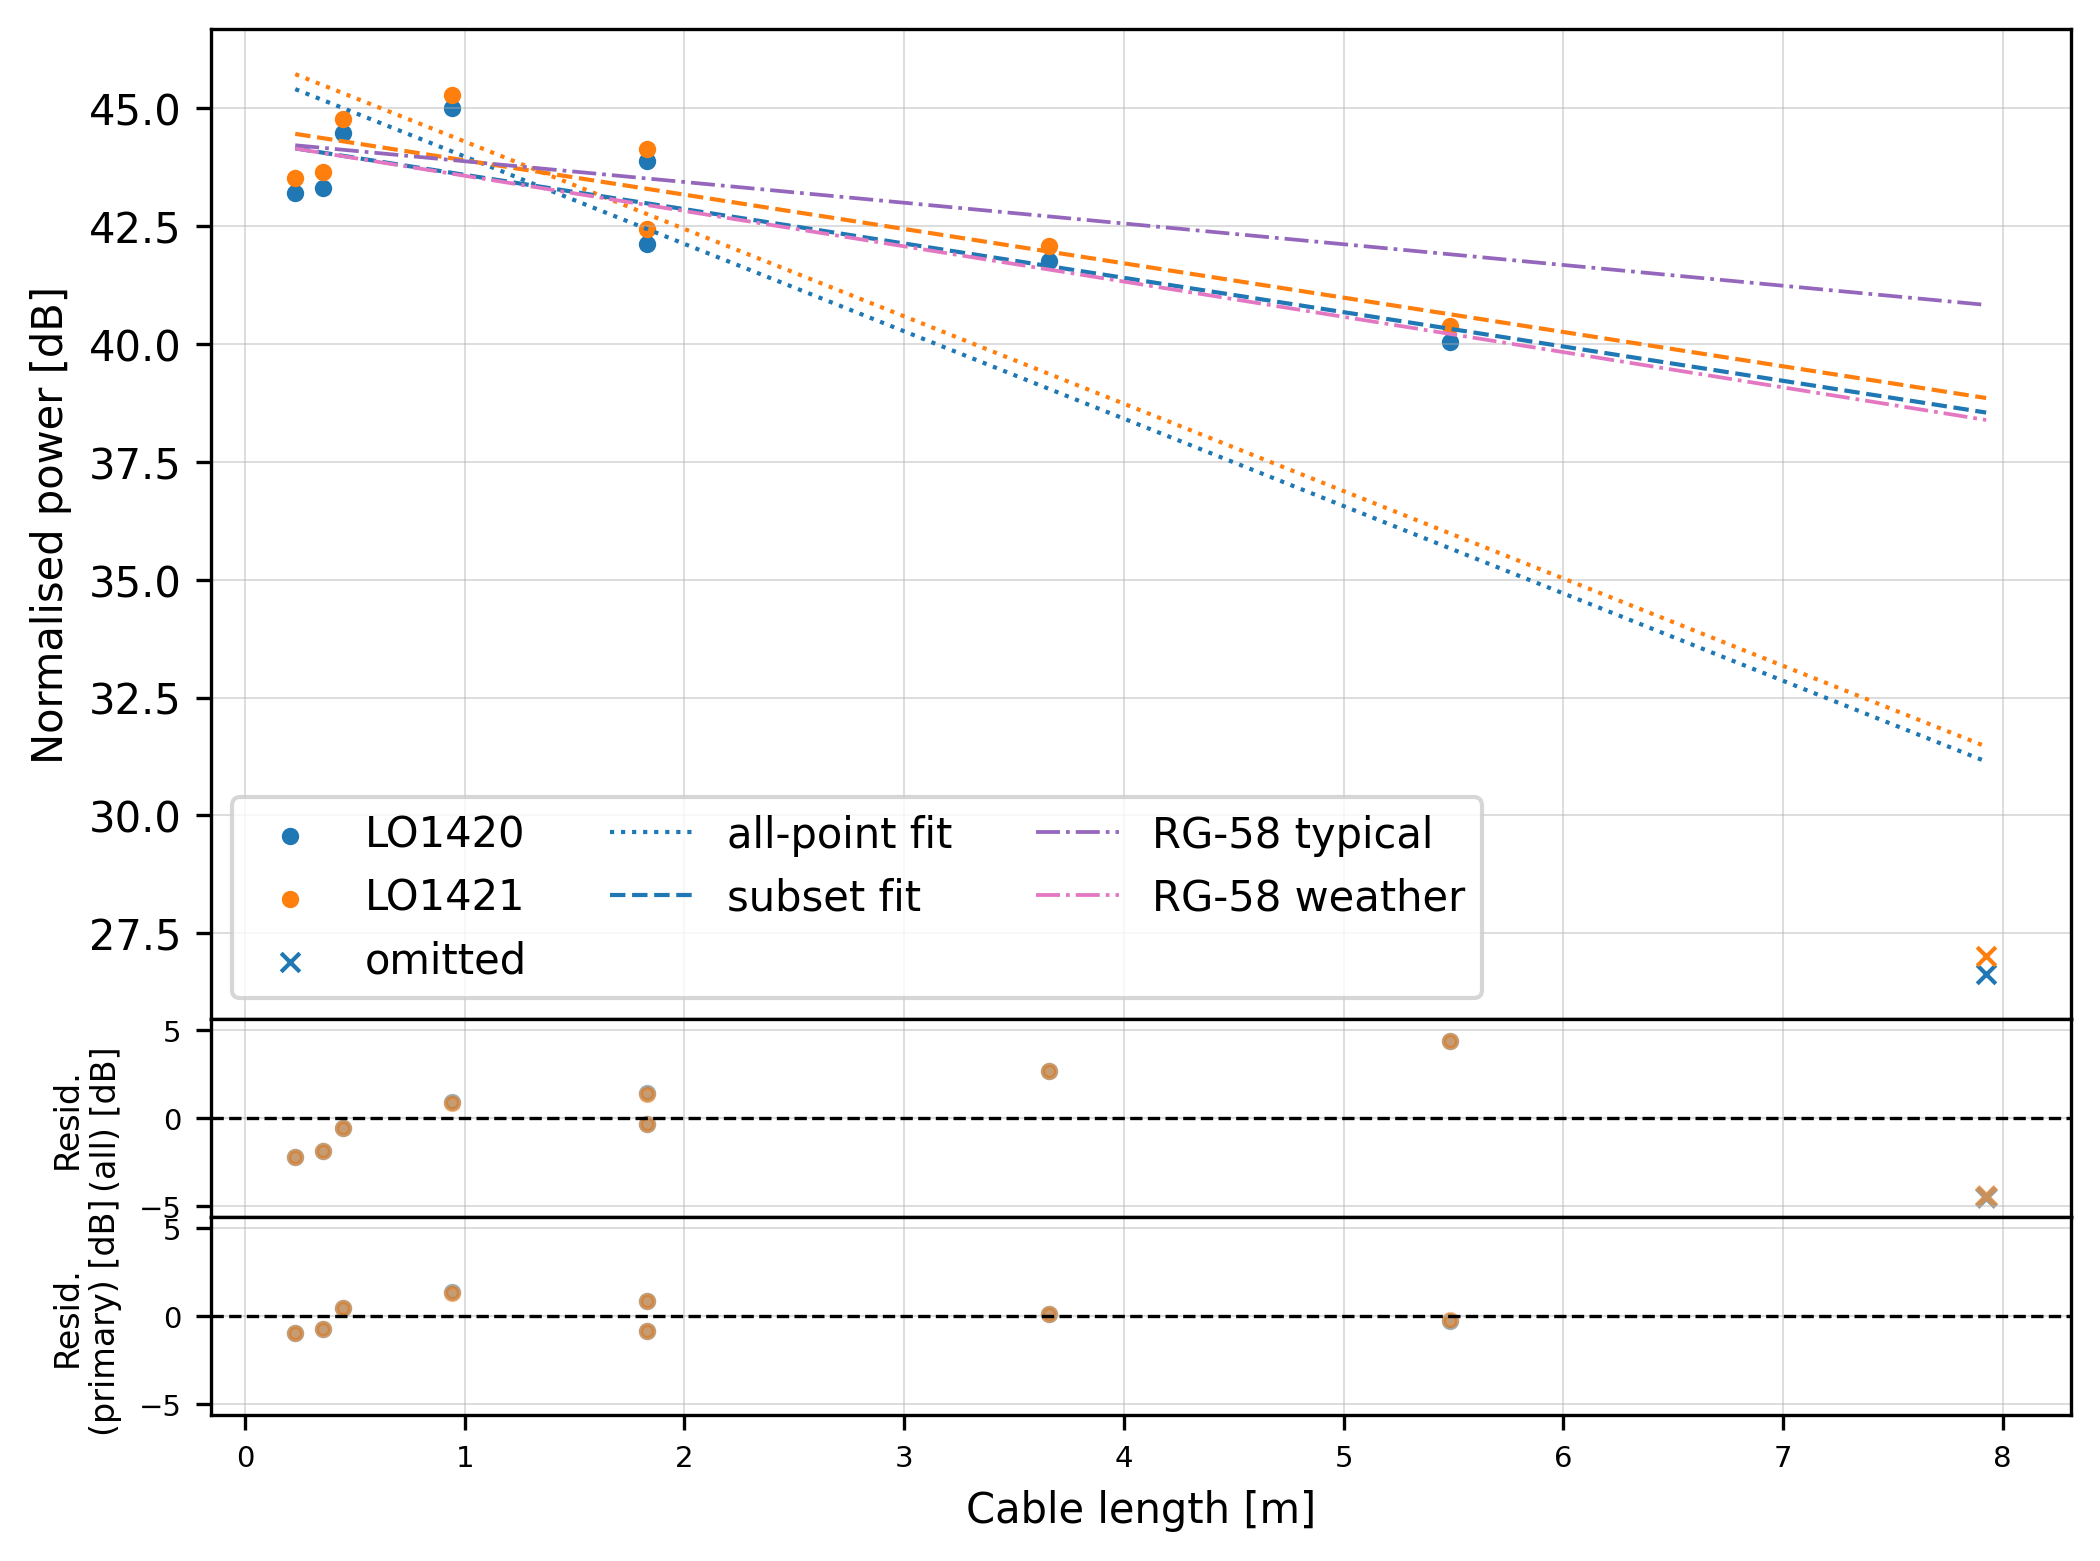

=== Shared linear SDR fit comparison ===


,n_rows,alpha [dB/m],sigma_alpha,B1420 [dB],B1421 [dB],RMSE [dB],AIC,BIC
fit_case,,,,,,,,
all-point,9,1.853179,0.260746,45.828144,46.145445,2.541461,39.578612,42.249727
primary-screened,8,0.728112,0.126931,44.314634,44.622445,0.795285,-1.329749,0.988017



Primary SDR fit selected: screened
  alpha = 0.728112 +/- 0.126931 dB/m
  deltaB = -0.3078 +/- 0.4411 dB
  RMSE   = 0.7953 dB


In [5]:
fit_lin_screened = fit_shared_linear(
    L, y1420, y1421,
    sigma_L=SIGMA_CAL_LENGTH_M,
    mc_samples=LENGTH_UNCERTAINTY_MC_SAMPLES,
    mc_seed=LENGTH_UNCERTAINTY_MC_SEED + 37,
)
fit_lin = fit_lin_screened if screening_applied else fit_lin_all   # primary SDR fit used downstream

L_line = np.linspace(np.min(L_all), np.max(L_all), 500)

def _line_y(B, alpha, x):
    return B - alpha * x

fig, axes = plt.subplots(
    3, 1, figsize=(8, 6),
    height_ratios=[5, 1, 1],
    sharex=True,
)
fig.subplots_adjust(hspace=0)

# ── Top panel: data + fits + RG-58 reference lines ───────────────────────────
ax = axes[0]
all_inlier = ~drop_mask
ax.scatter(L_all[all_inlier], y1420_all[all_inlier], color='C0', s=10, label='LO1420')
ax.scatter(L_all[all_inlier], y1421_all[all_inlier], color='C1', s=10, label='LO1421')
if np.any(~all_inlier):
    ax.scatter(L_all[~all_inlier], y1420_all[~all_inlier], color='C0', s=20, marker='x',
               lw=1.0, label='omitted')
    ax.scatter(L_all[~all_inlier], y1421_all[~all_inlier], color='C1', s=20, marker='x',
               lw=1.0)

ax.plot(L_line, _line_y(fit_lin_all['B1420'], fit_lin_all['alpha'], L_line),
        color='C0', lw=1.0, ls=':', label='all-point fit')
ax.plot(L_line, _line_y(fit_lin_all['B1421'], fit_lin_all['alpha'], L_line),
        color='C1', lw=1.0, ls=':')
ax.plot(L_line, _line_y(fit_lin['B1420'], fit_lin['alpha'], L_line),
        color='C0', lw=1.0, ls='--', label='subset fit')
ax.plot(L_line, _line_y(fit_lin['B1421'], fit_lin['alpha'], L_line),
        color='C1', lw=1.0, ls='--')

# RG-58 reference lines (same intercepts as primary fit, published slopes)
coax_refs = [
    ('RG-58 typical',     0.440, 'C4', '-.'),
    ('RG-58 weather', 0.748, 'C6', '-.'),
]
for label, alpha_ref, color, ls in coax_refs:
    ax.plot(L_line, _line_y(fit_lin['B1420'], alpha_ref, L_line),
            color=color, lw=0.9, ls=ls, label=label)

ax.set_ylabel('Normalised power [dB]')
ax.tick_params(labelbottom=False)
ax.grid(True, lw=0.4, alpha=0.5)
ax.legend(ncols=3)

# ── Middle panel: all-point fit residuals (includes screened points) ──────────
ax = axes[1]
ax.scatter(L_all[all_inlier], fit_lin_all['row_resid_1420'][all_inlier],
           color='C0', s=10, alpha=0.5)
ax.scatter(L_all[all_inlier], fit_lin_all['row_resid_1421'][all_inlier],
           color='C1', s=10, alpha=0.5)
if np.any(drop_mask):
    ax.scatter(L_all[drop_mask], fit_lin_all['row_resid_1420'][drop_mask],
               color='C0', s=20, alpha=0.6, marker='x', lw=1.5)
    ax.scatter(L_all[drop_mask], fit_lin_all['row_resid_1421'][drop_mask],
               color='C1', s=20, alpha=0.6, marker='x', lw=1.5)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.tick_params(labelbottom=False, labelsize=7)
ax.set_ylabel('Resid.\n(all) [dB]', fontsize=8)
ax.grid(True, lw=0.4, alpha=0.5)

# ── Bottom panel: primary (screened) fit residuals ────────────────────────────
ax = axes[2]
ax.scatter(L, fit_lin['row_resid_1420'], color='C0', s=10, alpha=0.5)
ax.scatter(L, fit_lin['row_resid_1421'], color='C1', s=10, alpha=0.5)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.tick_params(labelsize=7)
ax.set_xlabel('Cable length [m]')
ax.set_ylabel('Resid.\n(primary) [dB]', fontsize=8)
ax.grid(True, lw=0.4, alpha=0.5)

# Shared y-limits for both residual panels (use larger range)
all_resid = np.concatenate([
    fit_lin_all['row_resid_1420'], fit_lin_all['row_resid_1421'],
    fit_lin['row_resid_1420'],     fit_lin['row_resid_1421'],
])
rmax = np.nanmax(np.abs(all_resid)) * 1.25
for ax in (axes[1], axes[2]):
    ax.set_ylim(-rmax, rmax)

_nb_dir = Path('labs/02') if Path('labs/02').exists() else Path('.')
plt.savefig(_nb_dir / 'report' / 'figures' / 'cable_attenuation_lo.pdf', bbox_inches='tight')
plt.show()

fit_compare = pd.DataFrame([
    {
        'fit_case': 'all-point',
        'n_rows': len(L_all),
        'alpha [dB/m]': fit_lin_all['alpha'],
        'sigma_alpha': fit_lin_all['sigma_alpha'],
        'B1420 [dB]': fit_lin_all['B1420'],
        'B1421 [dB]': fit_lin_all['B1421'],
        'RMSE [dB]': fit_lin_all['rmse'],
        'AIC': fit_lin_all['aic'],
        'BIC': fit_lin_all['bic'],
    },
    {
        'fit_case': 'primary-screened' if screening_applied else 'primary-all-point',
        'n_rows': len(L),
        'alpha [dB/m]': fit_lin['alpha'],
        'sigma_alpha': fit_lin['sigma_alpha'],
        'B1420 [dB]': fit_lin['B1420'],
        'B1421 [dB]': fit_lin['B1421'],
        'RMSE [dB]': fit_lin['rmse'],
        'AIC': fit_lin['aic'],
        'BIC': fit_lin['bic'],
    },
]).set_index('fit_case')

print('=== Shared linear SDR fit comparison ===')
display(fit_compare.round(6))
print(f"\nPrimary SDR fit selected: {'screened' if screening_applied else 'all-point'}")
print(f"  alpha = {fit_lin['alpha']:.6f} +/- {fit_lin['sigma_alpha']:.6f} dB/m")
print(f"  deltaB = {fit_lin['deltaB']:.4f} +/- {fit_lin['sigma_deltaB']:.4f} dB")
print(f"  RMSE   = {fit_lin['rmse']:.4f} dB")


### SDR Fit Interpretation

Interpretation targets:

- Is a single physically meaningful slope `\alpha` supported across LO branches?
- Do residuals show random scatter around zero without systematic curvature?
- Do screened and all-point fits differ in a way consistent with leverage/outlier diagnostics?

## 8) Uncertainty Propagation (First-Order, `cal_intensity`-style)

We use first-order propagation with covariance terms retained.

For
$$
L=\frac{B-y}{\alpha},
$$

Jacobian terms are
$$
\frac{\partial L}{\partial B}=\frac{1}{\alpha},\qquad
\frac{\partial L}{\partial y}=-\frac{1}{\alpha},\qquad
\frac{\partial L}{\partial \alpha}=-\frac{L}{\alpha}.
$$

Variance (including covariance between `B` and `\alpha`):
$$
\sigma_L^2=
\left(\frac{\partial L}{\partial B}\right)^2\sigma_B^2+
\left(\frac{\partial L}{\partial y}\right)^2\sigma_y^2+
\left(\frac{\partial L}{\partial \alpha}\right)^2\sigma_\alpha^2+
2\frac{\partial L}{\partial B}\frac{\partial L}{\partial \alpha}\operatorname{Cov}(B,\alpha).
$$

Shared-SDR unknown-length uncertainty additionally uses the full covariance on `[B_{1420}, B_{1421}, \alpha]`.

In [6]:
alpha_hat = float(fit_lin['alpha'])
sigma_alpha = float(fit_lin['sigma_alpha'])
q16 = alpha_hat - sigma_alpha
q84 = alpha_hat + sigma_alpha
q025 = alpha_hat - 1.96 * sigma_alpha
q975 = alpha_hat + 1.96 * sigma_alpha

print('Analytic alpha (primary SDR fit):')
print(f'  estimate = {alpha_hat:.6f} dB/m')
print(f'  sigma    = {sigma_alpha:.6f} dB/m')
print(f'  68% CI   = [{q16:.6f}, {q84:.6f}] dB/m')
print(f'  95% CI   = [{q025:.6f}, {q975:.6f}] dB/m')
if q025 <= 0 <= q975:
    print('  WARNING: analytic 95% CI crosses 0 -> SDR inverse-length inference is weakly constrained.')

if screening_applied:
    alpha_all = float(fit_lin_all['alpha'])
    sigma_all = float(fit_lin_all['sigma_alpha'])
    q025_all = alpha_all - 1.96 * sigma_all
    q975_all = alpha_all + 1.96 * sigma_all
    print('\nAll-point analytic sensitivity (reference only):')
    print(f'  estimate = {alpha_all:.6f} dB/m')
    print(f'  sigma    = {sigma_all:.6f} dB/m')
    print(f'  95% CI   = [{q025_all:.6f}, {q975_all:.6f}] dB/m')


Analytic alpha (primary SDR fit):
  estimate = 0.728112 dB/m
  sigma    = 0.126931 dB/m
  68% CI   = [0.601181, 0.855043] dB/m
  95% CI   = [0.479327, 0.976897] dB/m

All-point analytic sensitivity (reference only):
  estimate = 1.853179 dB/m
  sigma    = 0.260746 dB/m
  95% CI   = [1.342116, 2.364241] dB/m


## 9) Model Scope and Why We Keep a Linear Attenuation Law

We intentionally keep the attenuation model linear in dB vs length for this dataset size.

- Sparse length sampling makes higher-order fits unstable.
- Unknown-length inversion is highly sensitive to slope uncertainty.
- Diagnostics are used to handle leverage/outlier behavior instead of adding unnecessary model degrees of freedom.

In [7]:
print('Attenuation model checks:')
print('  Shared-SDR model  : y_i(L) = B_i - alpha*L,  i in {1420,1421}')
print('  Meter model       : y_m(L) = B_m - alpha_m*L')
print('  Inversion formula : L = (B - y_obs)/alpha')
print()

# Basic physical sanity checks available at this stage (SDR fit already computed).
if not np.isfinite(fit_lin['alpha']):
    raise ValueError('Non-finite SDR attenuation slope encountered.')
if fit_lin['alpha'] <= 0:
    raise ValueError('SDR attenuation slope must be positive in dB/m for passive cable loss.')

# Sign-convention check: increasing length should decrease normalized power.
trial_delta_m = 1.0
trial_drop_sdr_db = (fit_lin['B1420'] - fit_lin['alpha'] * trial_delta_m) - fit_lin['B1420']
assert trial_drop_sdr_db < 0

print(f"Screening applied                 : {screening_applied}")
if screening_applied:
    print(f"  screened set_id values          : {df_diag.loc[drop_mask, 'set_id'].tolist()}")
print(f"Primary SDR alpha                 : {fit_lin['alpha']:.6f} +/- {fit_lin['sigma_alpha']:.6f} dB/m")
print(f"1 m predicted SDR drop            : {abs(trial_drop_sdr_db):.6f} dB")
print('Meter-branch slope sanity check is reported in the next section after meter fit execution.')


Attenuation model checks:
  Shared-SDR model  : y_i(L) = B_i - alpha*L,  i in {1420,1421}
  Meter model       : y_m(L) = B_m - alpha_m*L
  Inversion formula : L = (B - y_obs)/alpha

Screening applied                 : True
  screened set_id values          : [7]
Primary SDR alpha                 : 0.728112 +/- 0.126931 dB/m
1 m predicted SDR drop            : 0.728112 dB
Meter-branch slope sanity check is reported in the next section after meter fit execution.


## 10) Independent Meter-Branch Cross-Check

We fit the meter branch independently and compare attenuation slopes with SDR-based estimates.

Agreement supports a path-independent physical attenuation interpretation; disagreement indicates branch-specific systematic effects (termination mismatch, readout offsets, connector state, or compression).

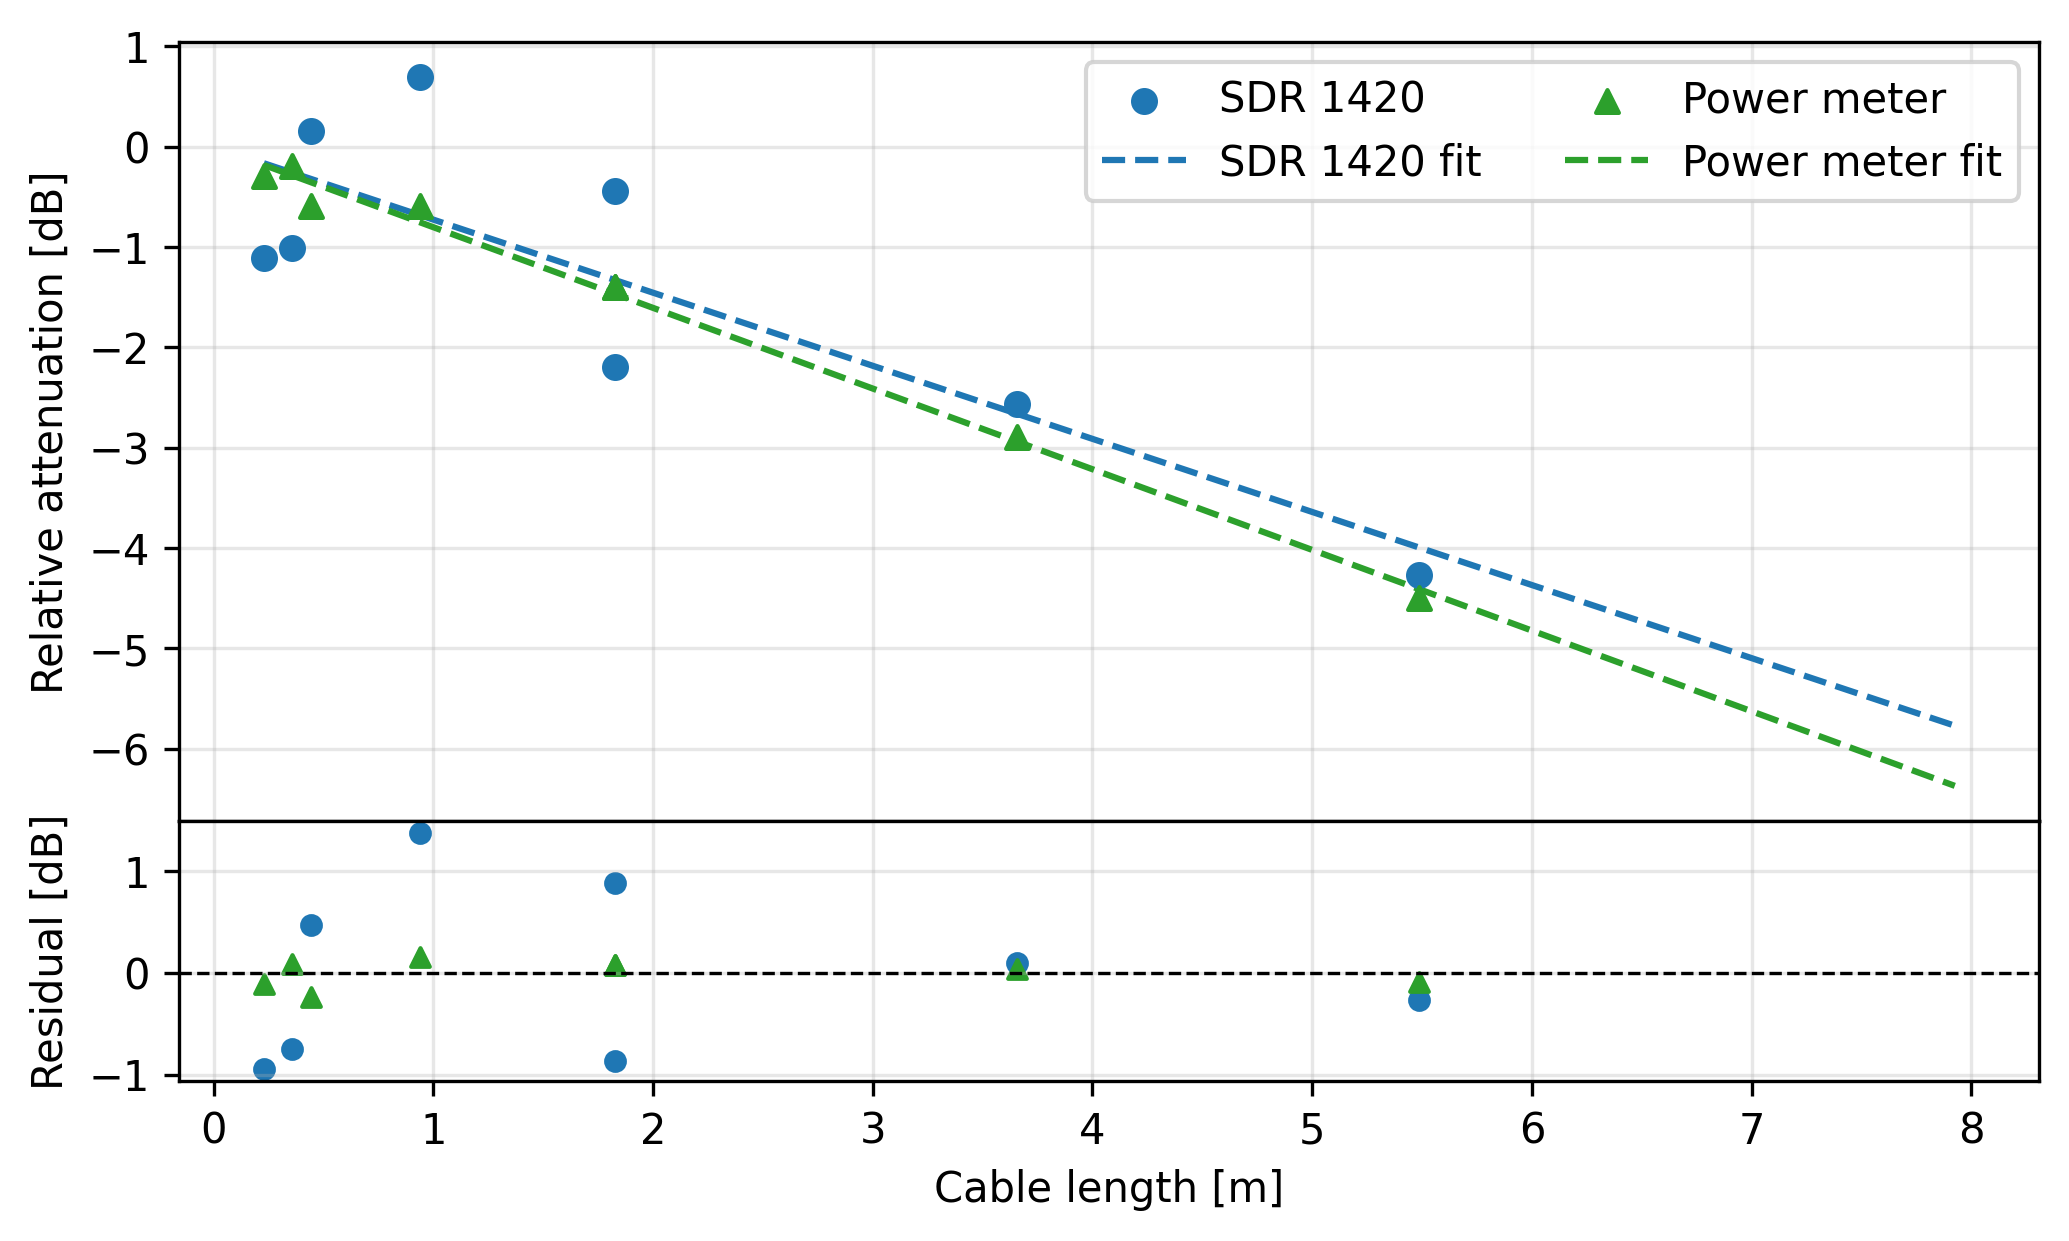

=== Meter linear fit comparison ===


,n_rows,alpha [dB/m],sigma_alpha,RMSE [dB],AIC,BIC
fit_case,,,,,,
all-point,9,1.915338,0.360765,2.402108,19.774240,20.168689
primary-screened,8,0.803730,0.029172,0.124171,-29.377563,-29.218680



Primary meter alpha = 0.803730 +/- 0.029172 dB/m
Meter analytic 95% CI on alpha = [0.746553, 0.860906] dB/m


In [8]:
fit_meter_all = fit_single_linear(
    L_all, meter_all,
    sigma_L=SIGMA_CAL_LENGTH_M,
    mc_samples=LENGTH_UNCERTAINTY_MC_SAMPLES,
    mc_seed=LENGTH_UNCERTAINTY_MC_SEED + 101,
)
fit_meter_screened = fit_single_linear(
    L, meter,
    sigma_L=SIGMA_CAL_LENGTH_M,
    mc_samples=LENGTH_UNCERTAINTY_MC_SAMPLES,
    mc_seed=LENGTH_UNCERTAINTY_MC_SEED + 131,
)
fit_meter = fit_meter_screened if screening_applied else fit_meter_all   # primary meter fit used downstream

m_alpha_hat = float(fit_meter['alpha'])
m_sigma_alpha = float(fit_meter['sigma_alpha'])
m_q025 = m_alpha_hat - 1.96 * m_sigma_alpha
m_q975 = m_alpha_hat + 1.96 * m_sigma_alpha

L_line = np.linspace(np.min(L_all), np.max(L_all), 500)

# Intercept-normalised: subtract each series' own B so both start at 0 dB
sdr_line_n   = -fit_lin['alpha']   * L_line
meter_line_n = -fit_meter['alpha'] * L_line
y1420_n      = y1420  - fit_lin['B1420']
meter_n      = meter  - fit_meter['B']

# Residuals
meter_resid = meter - (fit_meter['B'] - fit_meter['alpha'] * L)

fig, axes = plt.subplots(
    2, 1, figsize=(8, 4.5),
    height_ratios=[3, 1],
    sharex=True,
)
fig.subplots_adjust(hspace=0)

# ── Top panel: normalised SDR 1420 and power meter overlaid ──────────────────
ax = axes[0]
ax.scatter(L, y1420_n, color='C0', s=30, label='SDR 1420', zorder=4)
ax.plot(L_line, sdr_line_n, color='C0', lw=1.5, ls='--', label='SDR 1420 fit')
ax.scatter(L, meter_n, color='C2', s=30, marker='^', label='Power meter', zorder=4)
ax.plot(L_line, meter_line_n, color='C2', lw=1.5, ls='--', label='Power meter fit')
ax.set_ylabel('Relative attenuation [dB]')
ax.tick_params(labelbottom=False)
ax.legend(ncols=2)
ax.grid(alpha=0.3)

# ── Bottom panel: residuals ───────────────────────────────────────────────────
ax = axes[1]
ax.scatter(L, fit_lin['row_resid_1420'], color='C0', s=20)
ax.scatter(L, meter_resid, color='C2', s=20, marker='^')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Cable length [m]')
ax.set_ylabel('Residual [dB]')
ax.grid(alpha=0.3)

_nb_dir = Path('labs/02') if Path('labs/02').exists() else Path('.')
plt.savefig(_nb_dir / 'report' / 'figures' / 'cable_attenuation_power_meter.pdf', bbox_inches='tight')
plt.show()

meter_compare = pd.DataFrame([
    {
        'fit_case': 'all-point',
        'n_rows': len(L_all),
        'alpha [dB/m]': fit_meter_all['alpha'],
        'sigma_alpha': fit_meter_all['sigma_alpha'],
        'RMSE [dB]': fit_meter_all['rmse'],
        'AIC': fit_meter_all['aic'],
        'BIC': fit_meter_all['bic'],
    },
    {
        'fit_case': 'primary-screened' if screening_applied else 'primary-all-point',
        'n_rows': len(L),
        'alpha [dB/m]': fit_meter['alpha'],
        'sigma_alpha': fit_meter['sigma_alpha'],
        'RMSE [dB]': fit_meter['rmse'],
        'AIC': fit_meter['aic'],
        'BIC': fit_meter['bic'],
    },
]).set_index('fit_case')

print('=== Meter linear fit comparison ===')
display(meter_compare.round(6))
print()
print(f"Primary meter alpha = {fit_meter['alpha']:.6f} +/- {fit_meter['sigma_alpha']:.6f} dB/m")
print(f"Meter analytic 95% CI on alpha = [{m_q025:.6f}, {m_q975:.6f}] dB/m")


In [9]:
# ── Port-2 cable deferred correction ────────────────────────────────────────
# The 6-ft cable between splitter port 2 and the 3 dB attenuator adds:
PORT2_CABLE_LOSS_DB = fit_lin['alpha'] * PORT2_CABLE_LEN_M
y1420_fully_corrected = y1420_corr + PORT2_CABLE_LOSS_DB
y1421_fully_corrected = y1421_corr + PORT2_CABLE_LOSS_DB
# Note: this doesn't change alpha; the fit intercepts shift by PORT2_CABLE_LOSS_DB.

print(f'alpha (SDR linear, unchanged)       : {fit_lin["alpha"]:.6f} dB/m')
print(f'Port-2 cable deferred correction    : +{PORT2_CABLE_LOSS_DB:.4f} dB'
      f'  ({fit_lin["alpha"]:.6f} dB/m × {PORT2_CABLE_LEN_M:.4f} m)')
print()
print('Corrected intercepts (fully corrected = power at cable output, before splitter):')
B1420_corr = fit_lin['B1420'] + SDR_FIXED_CORRECTION_DB + PORT2_CABLE_LOSS_DB
B1421_corr = fit_lin['B1421'] + SDR_FIXED_CORRECTION_DB + PORT2_CABLE_LOSS_DB
B_meter_corr = fit_meter['B'] + SPLITTER_S1_DB
print(f'  B1420_corrected = {B1420_corr:.4f} dB')
print(f'  B1421_corrected = {B1421_corr:.4f} dB')
print(f'  B_meter_corrected = {B_meter_corr:.4f} dB')
print()
print('Note: L_unknown inference is unchanged because the same path corrections')
print('apply identically to calibration and unknown-length sets, cancelling in')
print('L = (B - y_obs) / alpha.')


alpha (SDR linear, unchanged)       : 0.728112 dB/m
Port-2 cable deferred correction    : +1.3316 dB  (0.728112 dB/m × 1.8288 m)

Corrected intercepts (fully corrected = power at cable output, before splitter):
  B1420_corrected = 51.9942 dB
  B1421_corrected = 52.3020 dB
  B_meter_corrected = -0.3301 dB

Note: L_unknown inference is unchanged because the same path corrections
apply identically to calibration and unknown-length sets, cancelling in
L = (B - y_obs) / alpha.


## 11) Voltage-Space Cross-Check (50 Ohm Matched Assumption)

We convert power-meter dBm readings to equivalent `V_rms` and `V_pp` under a matched 50 Ohm load.

This is an internal sanity check only, not the primary calibration path.

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd


def dbm_to_watts(p_dbm: float) -> float:
    return 1e-3 * (10.0 ** (p_dbm / 10.0))


def watts_to_vrms(p_w: float, r_ohm: float = 50.0) -> float:
    return float(np.sqrt(max(p_w, 0.0) * r_ohm))


def vrms_to_vpp(v_rms: float) -> float:
    return float(2.0 * np.sqrt(2.0) * v_rms)


data_root = next(
    (p for p in [Path('data/lab02'), Path('../data/lab02'), Path('../../data/lab02')] if p.exists()),
    Path('data/lab02'),
)
if 'df_att_used' in globals():
    meter_df = df_att_used[['set_id', 'cable_length_m', 'power_meter_dbm']].copy()
elif 'df_att' in globals():
    meter_df = df_att[['set_id', 'cable_length_m', 'power_meter_dbm']].copy()
else:
    meter_df = pd.read_csv(data_root / 'attenuation' / 'manifest.csv')[
        ['set_id', 'cable_length_m', 'power_meter_dbm']
    ].copy()

meter_df['power_w'] = meter_df['power_meter_dbm'].map(dbm_to_watts)
meter_df['v_rms_v'] = meter_df['power_w'].map(watts_to_vrms)
meter_df['v_pp_v'] = meter_df['v_rms_v'].map(vrms_to_vpp)

print('Power-meter conversion cross-check (assuming 50 Ohm load):')
display(
    meter_df.sort_values(['cable_length_m', 'set_id']).reset_index(drop=True)
)

Power-meter conversion cross-check (assuming 50 Ohm load):


,set_id,cable_length_m,power_meter_dbm,power_w,v_rms_v,v_pp_v
0,1,0.2286,-14.0,0.000040,0.044615,0.126191
1,2,0.3556,-8.9,0.000129,0.080257,0.227002
2,6,0.4445,-14.3,0.000037,0.043101,0.121907
3,4,0.9398,-9.3,0.000117,0.076645,0.216785
4,3,1.8288,-10.1,0.000098,0.069901,0.197711
5,5,1.8288,-10.1,0.000098,0.069901,0.197711
6,8,3.6576,-11.6,0.000069,0.058815,0.166353
7,9,5.4864,-13.2,0.000048,0.048920,0.138366


## 12) Bench Analog Measurement Log (2026-03-07)

This section documents the measured A1-A5 chain configurations and derives block-level gain/loss metrics.

It provides:

- chain closure checks,
- unknown-cable bench estimate for consistency,
- conservative drive-level safety guidance for cascaded amplifier tests.

In [11]:
import numpy as np
import pandas as pd

ANALOG_TEST_DATE = '2026-03-07'
ANALOG_TONE_MHZ = 1420.405751768
ANALOG_SIGGEN_DBM = 20.0

POWER_METER_DIVISION_DB = 0.2
POWER_METER_UNCERTAINTY_DB = POWER_METER_DIVISION_DB / 2.0  # +/- 0.1 dB per reading
CHAIN_DELTA_UNCERTAINTY_DB = np.sqrt(2.0) * POWER_METER_UNCERTAINTY_DB

bench_rows = [
    {
        'setup_id': 'A1_ref_2x6ft',
        'purpose': 'Reference path (two 6-ft cables)',
        'path': 'siggen -> 6-ft -> 6-ft -> power meter',
        'p_in_dbm': ANALOG_SIGGEN_DBM,
        'p_out_dbm': 15.7,
    },
    {
        'setup_id': 'A2_unknown_only',
        'purpose': 'Unknown cable loss measurement',
        'path': 'siggen -> 6-ft -> 6-ft -> unknown cable -> power meter',
        'p_in_dbm': ANALOG_SIGGEN_DBM,
        'p_out_dbm': -13.6,
    },
    {
        'setup_id': 'A3_roof_chain',
        'purpose': 'Unknown cable + (ZKL + Reactel + ZKL + ZKL)',
        'path': 'A2 path + 6-ft + ZKL -> Reactel -> ZKL -> ZKL -> power meter',
        'p_in_dbm': ANALOG_SIGGEN_DBM,
        'p_out_dbm': 17.9,
    },
    {
        'setup_id': 'A4_lab_chain',
        'purpose': 'K&L + wideband amp + narrowband amp',
        'path': 'siggen -> 6-ft -> 6-ft -> K&L -> wideband amp -> narrowband amp -> power meter',
        'p_in_dbm': ANALOG_SIGGEN_DBM,
        'p_out_dbm': 7.5,
    },
    {
        'setup_id': 'A5_lab_filter_only',
        'purpose': 'K&L insertion loss only',
        'path': 'siggen -> 6-ft -> 6-ft -> K&L -> power meter',
        'p_in_dbm': ANALOG_SIGGEN_DBM,
        'p_out_dbm': -4.6,
    },
]

df_bench = pd.DataFrame(bench_rows)
df_bench['p_in_sigma_dbm'] = POWER_METER_UNCERTAINTY_DB
df_bench['p_out_sigma_dbm'] = POWER_METER_UNCERTAINTY_DB
df_bench['chain_delta_db'] = df_bench['p_out_dbm'] - df_bench['p_in_dbm']
df_bench['chain_delta_uncertainty_db'] = CHAIN_DELTA_UNCERTAINTY_DB

print(f"Power-meter smallest division: {POWER_METER_DIVISION_DB:.1f} dB")
print(f"Per-reading uncertainty proxy : +/- {POWER_METER_UNCERTAINTY_DB:.3f} dB")
print(f"Delta uncertainty (two reads) : +/- {CHAIN_DELTA_UNCERTAINTY_DB:.3f} dB")

columns = [
    'setup_id', 'purpose', 'p_in_dbm', 'p_in_sigma_dbm', 'p_out_dbm', 'p_out_sigma_dbm',
    'chain_delta_db', 'chain_delta_uncertainty_db', 'path'
]
display(df_bench[columns])

def _pout(setup_id: str) -> float:
    return float(df_bench.loc[df_bench['setup_id'] == setup_id, 'p_out_dbm'].iloc[0])

m_ref = _pout('A1_ref_2x6ft')
m_unknown = _pout('A2_unknown_only')
m_roof = _pout('A3_roof_chain')
m_lab_full = _pout('A4_lab_chain')
m_kl_only = _pout('A5_lab_filter_only')

bench_metrics = {
    'baseline_loss_db': ANALOG_SIGGEN_DBM - m_ref,
    'unknown_incremental_loss_db': m_ref - m_unknown,
    'roof_chain_net_gain_db': m_roof - m_unknown,
    'kl_filter_incremental_loss_db': m_ref - m_kl_only,
    'wide_narrow_net_gain_db': m_lab_full - m_kl_only,
    'lab_net_vs_baseline_db': m_lab_full - m_ref,
}

closure_tol_db = 0.05
closure_checks = {
    'A2 + roof_gain == A3': abs((m_unknown + bench_metrics['roof_chain_net_gain_db']) - m_roof),
    'A5 + wide_narrow_gain == A4': abs((m_kl_only + bench_metrics['wide_narrow_net_gain_db']) - m_lab_full),
}

metric_rows = []
for k, v in bench_metrics.items():
    metric_rows.append(
        {
            'metric': k,
            'value_db': v,
            'sigma_db': CHAIN_DELTA_UNCERTAINTY_DB,
            'value_pm_sigma_db': f"{v:.3f} +/- {CHAIN_DELTA_UNCERTAINTY_DB:.3f}",
        }
    )
df_bench_metrics = pd.DataFrame(metric_rows)
display(df_bench_metrics)

print('Self-consistency closure checks:')
for name, err in closure_checks.items():
    status = 'PASS' if err <= closure_tol_db else 'CHECK'
    print(f'  {name}: residual={err:.4f} dB  ->  {status} (tol={closure_tol_db:.3f} dB)')

# Bench unknown-length estimate (meter branch) with propagated uncertainty.
if 'fit_meter' in globals() and np.isfinite(fit_meter['alpha']) and abs(fit_meter['alpha']) > 1e-12:
    alpha_m = float(fit_meter['alpha'])
    sigma_alpha_m = float(fit_meter['sigma_alpha'])
    delta_unknown_db = bench_metrics['unknown_incremental_loss_db']
    sigma_delta_unknown_db = CHAIN_DELTA_UNCERTAINTY_DB

    L_unknown_bench_meter_m = delta_unknown_db / alpha_m
    sigma_L_alpha = abs(delta_unknown_db / (alpha_m ** 2)) * sigma_alpha_m
    sigma_L_measurement = sigma_delta_unknown_db / abs(alpha_m)
    sigma_L_bench_meter_total = np.sqrt(sigma_L_alpha ** 2 + sigma_L_measurement ** 2)

    print('\nBench-derived unknown length (meter slope):')
    print(f'  Delta loss                    = {delta_unknown_db:.4f} +/- {sigma_delta_unknown_db:.4f} dB')
    print(f'  L_unknown_bench_meter         = {L_unknown_bench_meter_m:.4f} +/- {sigma_L_bench_meter_total:.4f} m')
    print(f'    sigma(alpha term)           = {sigma_L_alpha:.4f} m')
    print(f'    sigma(measurement term)     = {sigma_L_measurement:.4f} m')
    L_unknown_bench_meter_sigma_m = float(sigma_L_bench_meter_total)
else:
    L_unknown_bench_meter_m = np.nan
    L_unknown_bench_meter_sigma_m = np.nan
    print('\nfit_meter is not available; run Cell 10 first to compute bench unknown length.')

# Datasheet references used for safety/compression checks.
df_chain_parts = pd.DataFrame([
    {
        'component': 'Mini-Circuits ZKL-33ULN-S+',
        'datasheet_url': 'https://www.minicircuits.com/pdfs/ZKL-33ULN-S%2B.pdf',
        'parameters_used': 'Gain~26.8 dB @1500 MHz; Pout@1dB~36.8 dBm; max input no-damage <= 0 dBm near 1.5 GHz',
    },
    {
        'component': 'Reactel 1420-15S11 BPF',
        'datasheet_url': 'https://reactel.com/',
        'parameters_used': 'Exact model-sheet insertion loss at 1420.4058 MHz not yet loaded; 2.0 dB assumed for safety margin calc',
    },
    {
        'component': 'K&L 5B120-1380/160-0 BPF',
        'datasheet_url': 'https://www.smithsinterconnect.com/products/frequency-defined-filters/rf-filters/',
        'parameters_used': 'Exact model-sheet insertion loss not yet loaded in notebook; measured chain deltas used directly',
    },
])
display(df_chain_parts)

# Compression/safety estimate with first-order uncertainty from meter reads.
per_6ft_loss_est_db = (ANALOG_SIGGEN_DBM - m_ref) / 2.0
sigma_per_6ft_loss_db = POWER_METER_UNCERTAINTY_DB / 2.0
p_stage1_in_est_dbm = m_unknown - per_6ft_loss_est_db
sigma_p_stage1_dbm = np.sqrt(POWER_METER_UNCERTAINTY_DB**2 + sigma_per_6ft_loss_db**2)

ZKL_GAIN_TYP_DB_1420 = 26.8
ZKL_POUT_1DB_DBM_1420 = 36.8
ZKL_PIN_1DB_DBM_1420 = ZKL_POUT_1DB_DBM_1420 - ZKL_GAIN_TYP_DB_1420
ZKL_PIN_NO_DAMAGE_LIMIT_DBM_1420 = 0.0
REACTEL_IL_ASSUMED_DB = 2.0

p_stage2_in_est_dbm = p_stage1_in_est_dbm + ZKL_GAIN_TYP_DB_1420 - REACTEL_IL_ASSUMED_DB
p_stage3_in_est_dbm_small_signal = p_stage2_in_est_dbm + ZKL_GAIN_TYP_DB_1420
sigma_p_stage2_dbm = sigma_p_stage1_dbm
sigma_p_stage3_dbm = sigma_p_stage2_dbm

over_no_damage_db = max(0.0, p_stage2_in_est_dbm - ZKL_PIN_NO_DAMAGE_LIMIT_DBM_1420)
safe_siggen_dbm_est = ANALOG_SIGGEN_DBM - over_no_damage_db
safe_siggen_sigma_db = sigma_p_stage2_dbm if over_no_damage_db > 0 else np.nan

print('\nZKL-33ULN-S+ safety/compression check (bench estimate):')
print(f'  Estimated amp1 input                : {p_stage1_in_est_dbm:.2f} +/- {sigma_p_stage1_dbm:.2f} dBm')
print(f'  Estimated amp2 input (small-signal) : {p_stage2_in_est_dbm:.2f} +/- {sigma_p_stage2_dbm:.2f} dBm')
print(f'  Estimated amp3 input (small-signal) : {p_stage3_in_est_dbm_small_signal:.2f} +/- {sigma_p_stage3_dbm:.2f} dBm')
print(f'  ZKL input P1dB (derived)            : {ZKL_PIN_1DB_DBM_1420:.2f} dBm')
print(f'  ZKL no-damage input limit (used)    : {ZKL_PIN_NO_DAMAGE_LIMIT_DBM_1420:.2f} dBm')
if np.isfinite(safe_siggen_sigma_db):
    print(f'  Recommended max siggen setpoint     : <= {safe_siggen_dbm_est:.2f} +/- {safe_siggen_sigma_db:.2f} dBm (conservative)')
else:
    print(f'  Recommended max siggen setpoint     : <= {safe_siggen_dbm_est:.2f} dBm (conservative)')

if p_stage2_in_est_dbm > ZKL_PIN_1DB_DBM_1420 or p_stage3_in_est_dbm_small_signal > ZKL_PIN_1DB_DBM_1420:
    print('  WARNING: estimated cascaded-amp inputs exceed P1dB; compression is likely in high-drive tests.')
if p_stage2_in_est_dbm > ZKL_PIN_NO_DAMAGE_LIMIT_DBM_1420:
    print('  WARNING: estimated amp2 input exceeds the no-damage limit used for this frequency range.')

Power-meter smallest division: 0.2 dB
Per-reading uncertainty proxy : +/- 0.100 dB
Delta uncertainty (two reads) : +/- 0.141 dB


,setup_id,purpose,p_in_dbm,p_in_sigma_dbm,p_out_dbm,p_out_sigma_dbm,chain_delta_db,chain_delta_uncertainty_db,path
0,A1_ref_2x6ft,Reference path (two 6-ft cables),20.0,0.1,15.7,0.1,-4.3,0.141421,siggen -> 6-ft -> 6-ft -> power meter
1,A2_unknown_only,Unknown cable loss measurement,20.0,0.1,-13.6,0.1,-33.6,0.141421,siggen -> 6-ft -> 6-ft -> unknown cable -> pow...
2,A3_roof_chain,Unknown cable + (ZKL + Reactel + ZKL + ZKL),20.0,0.1,17.9,0.1,-2.1,0.141421,A2 path + 6-ft + ZKL -> Reactel -> ZKL -> ZKL ...
3,A4_lab_chain,K&L + wideband amp + narrowband amp,20.0,0.1,7.5,0.1,-12.5,0.141421,siggen -> 6-ft -> 6-ft -> K&L -> wideband amp ...
4,A5_lab_filter_only,K&L insertion loss only,20.0,0.1,-4.6,0.1,-24.6,0.141421,siggen -> 6-ft -> 6-ft -> K&L -> power meter


,metric,value_db,sigma_db,value_pm_sigma_db
0,baseline_loss_db,4.3,0.141421,4.300 +/- 0.141
1,unknown_incremental_loss_db,29.3,0.141421,29.300 +/- 0.141
2,roof_chain_net_gain_db,31.5,0.141421,31.500 +/- 0.141
3,kl_filter_incremental_loss_db,20.3,0.141421,20.300 +/- 0.141
4,wide_narrow_net_gain_db,12.1,0.141421,12.100 +/- 0.141
5,lab_net_vs_baseline_db,-8.2,0.141421,-8.200 +/- 0.141


Self-consistency closure checks:
  A2 + roof_gain == A3: residual=0.0000 dB  ->  PASS (tol=0.050 dB)
  A5 + wide_narrow_gain == A4: residual=0.0000 dB  ->  PASS (tol=0.050 dB)

Bench-derived unknown length (meter slope):
  Delta loss                    = 29.3000 +/- 0.1414 dB
  L_unknown_bench_meter         = 36.4550 +/- 1.3348 m
    sigma(alpha term)           = 1.3231 m
    sigma(measurement term)     = 0.1760 m


,component,datasheet_url,parameters_used
0,Mini-Circuits ZKL-33ULN-S+,https://www.minicircuits.com/pdfs/ZKL-33ULN-S%...,Gain~26.8 dB @1500 MHz; Pout@1dB~36.8 dBm; max...
1,Reactel 1420-15S11 BPF,https://reactel.com/,Exact model-sheet insertion loss at 1420.4058 ...
2,K&L 5B120-1380/160-0 BPF,https://www.smithsinterconnect.com/products/fr...,Exact model-sheet insertion loss not yet loade...



ZKL-33ULN-S+ safety/compression check (bench estimate):
  Estimated amp1 input                : -15.75 +/- 0.11 dBm
  Estimated amp2 input (small-signal) : 9.05 +/- 0.11 dBm
  Estimated amp3 input (small-signal) : 35.85 +/- 0.11 dBm
  ZKL input P1dB (derived)            : 10.00 dBm
  ZKL no-damage input limit (used)    : 0.00 dBm
  Recommended max siggen setpoint     : <= 10.95 +/- 0.11 dBm (conservative)


### Filter/Amplifier Ordering and Noise Implications

Ordering affects both gain distribution and total in-band/out-of-band noise delivered to the ADC.

Following the logic in `horn_signal_chain_test.tex` and `bighorn.tex`, the objective is to preserve enough gain for robust digitization while constraining out-of-band amplification and reflection-induced artifacts.

## 13) Unknown-Cable Inversion and Primary-Estimate Selection

Unknown-length estimates:

$$
L_{1420}=\frac{B_{1420}-y_{1420}^{obs}}{\alpha},\quad
L_{1421}=\frac{B_{1421}-y_{1421}^{obs}}{\alpha},
$$
$$
L_{SDR}=\frac{L_{1420}+L_{1421}}{2},\quad
L_{meter}=\frac{B_{meter}-y_{meter}^{obs}}{\alpha_{meter}},
$$
$$
L_{unknown}=L_{total}-L_{lead}.
$$

Primary-source decision is criterion-based (SDR first; meter fallback if SDR stability criteria fail).

In [12]:
# Observed (normalised) values for the unknown manifest set
y0_obs = float(df_unk['y_lo1420_db'].iloc[0])
y1_obs = float(df_unk['y_lo1421_db'].iloc[0])
ym_obs = float(df_unk['power_meter_norm_db'].iloc[0])

print('Unknown manifest set observations (normalised):')
print(f'  y_1420_norm = {y0_obs:.4f} dB')
print(f'  y_1421_norm = {y1_obs:.4f} dB')
print(f'  y_meter_norm = {ym_obs:.4f} dB')
print(f'  lead-length sigma (meter rule) = +/- {SIGMA_LEAD_LENGTH_M*1e3:.3f} mm')

# Inference: manifest linear model inversion.
lin_result = infer_unknown_length_linear(y0_obs, y1_obs, fit_lin)
L0_total = float(lin_result['L0'])
L1_total = float(lin_result['L1'])
L_total_lin = float(lin_result['L_total'])

L_meter_total = (fit_meter['B'] - ym_obs) / fit_meter['alpha']

L_unknown_lin = L_total_lin - UNKNOWN_LEAD_LENGTH_M
L_meter_unknown = L_meter_total - UNKNOWN_LEAD_LENGTH_M
L0_unknown = L0_total - UNKNOWN_LEAD_LENGTH_M
L1_unknown = L1_total - UNKNOWN_LEAD_LENGTH_M

# Observation-noise proxy for unknown manifest set: model RMSE in dB.
sigma_y_sdr_obs = float(fit_lin['rmse'])
sigma_y_meter_obs = float(fit_meter['rmse'])

# Meter-path propagated sigma on L_total including model covariance and y-observation noise.
cov_m = np.asarray(fit_meter['cov'], float)
sigma_L_meter_total = propagate_length_sigma(
    fit_meter['B'], ym_obs, fit_meter['alpha'],
    fit_meter['sigma_B'], fit_meter['sigma_alpha'],
    cov_B_alpha=float(cov_m[0, 1]),
    sigma_y=sigma_y_meter_obs,
)
sigma_L_meter_unknown = float(np.sqrt(sigma_L_meter_total**2 + SIGMA_LEAD_LENGTH_M**2))

# SDR individual-channel propagated sigmas.
cov_s = np.asarray(fit_lin['cov'], float)
sigma_L0_total = propagate_length_sigma(
    fit_lin['B1420'], y0_obs, fit_lin['alpha'],
    fit_lin['sigma_B1420'], fit_lin['sigma_alpha'],
    cov_B_alpha=float(cov_s[0, 2]),
    sigma_y=sigma_y_sdr_obs,
)
sigma_L1_total = propagate_length_sigma(
    fit_lin['B1421'], y1_obs, fit_lin['alpha'],
    fit_lin['sigma_B1421'], fit_lin['sigma_alpha'],
    cov_B_alpha=float(cov_s[1, 2]),
    sigma_y=sigma_y_sdr_obs,
)
sigma_L0_unknown = float(np.sqrt(sigma_L0_total**2 + SIGMA_LEAD_LENGTH_M**2))
sigma_L1_unknown = float(np.sqrt(sigma_L1_total**2 + SIGMA_LEAD_LENGTH_M**2))

# SDR mean-path propagated sigma on L_total using full Jacobian on theta=[B1420,B1421,alpha].
alpha = float(fit_lin['alpha'])
J_theta = np.array([
    1.0 / (2.0 * alpha),
    1.0 / (2.0 * alpha),
    -(L0_total + L1_total) / (2.0 * alpha),
], dtype=float)
var_theta = float(J_theta @ cov_s @ J_theta)

# y-observation terms for LO1420 and LO1421, treated independent at first order.
dLdy = -1.0 / (2.0 * alpha)
var_y = (dLdy**2) * (sigma_y_sdr_obs**2 + sigma_y_sdr_obs**2)

sigma_L_lin_total = float(np.sqrt(max(var_theta + var_y, 0.0)))
sigma_L_lin_analytic = float(np.sqrt(sigma_L_lin_total**2 + SIGMA_LEAD_LENGTH_M**2))

L_unknown_ci68 = (L_unknown_lin - sigma_L_lin_analytic, L_unknown_lin + sigma_L_lin_analytic)
L_unknown_ci95 = (L_unknown_lin - 1.96 * sigma_L_lin_analytic, L_unknown_lin + 1.96 * sigma_L_lin_analytic)

print()
print('=== Manifest-based linear inference ===')
print(f'  SDR LO1420  : L_total = {L0_total:.4f} +/- {sigma_L0_total:.4f} m  ->  L_unknown = {L0_unknown:.4f} +/- {sigma_L0_unknown:.4f} m')
print(f'  SDR LO1421  : L_total = {L1_total:.4f} +/- {sigma_L1_total:.4f} m  ->  L_unknown = {L1_unknown:.4f} +/- {sigma_L1_unknown:.4f} m')
print(f'  SDR mean    : L_total = {L_total_lin:.4f} +/- {sigma_L_lin_total:.4f} m  ->  L_unknown = {L_unknown_lin:.4f} +/- {sigma_L_lin_analytic:.4f} m')
print(f'  Meter       : L_total = {L_meter_total:.4f} +/- {sigma_L_meter_total:.4f} m  ->  L_unknown = {L_meter_unknown:.4f} +/- {sigma_L_meter_unknown:.4f} m')
print(f'  SDR analytic 68% CI on L_unknown = [{L_unknown_ci68[0]:.4f}, {L_unknown_ci68[1]:.4f}] m')
print(f'  SDR analytic 95% CI on L_unknown = [{L_unknown_ci95[0]:.4f}, {L_unknown_ci95[1]:.4f}] m')

# Criterion-based primary-estimate selection: prefer SDR unless stability checks fail.
sdr_rule_reasons = []
alpha_ci95_crosses_zero = (q025 <= 0.0 <= q975)
if PRIMARY_RULE_REQUIRE_POSITIVE_ALPHA_CI95 and alpha_ci95_crosses_zero:
    sdr_rule_reasons.append('SDR analytic alpha 95% CI crosses zero')

rel_ci95_width = (L_unknown_ci95[1] - L_unknown_ci95[0]) / max(abs(L_unknown_lin), 1e-9)
if np.isfinite(rel_ci95_width) and rel_ci95_width > PRIMARY_RULE_MAX_RELATIVE_CI95_WIDTH:
    sdr_rule_reasons.append(
        f'SDR analytic L_unknown 95% CI width/|estimate| = {rel_ci95_width:.2f} > {PRIMARY_RULE_MAX_RELATIVE_CI95_WIDTH:.2f}'
    )

if sdr_rule_reasons:
    primary_length_source = 'manifest_meter_linear_fallback'
    L_unknown_primary = float(L_meter_unknown)
    L_unknown_primary_sigma = float(sigma_L_meter_unknown)
else:
    primary_length_source = 'manifest_sdr_linear'
    L_unknown_primary = float(L_unknown_lin)
    L_unknown_primary_sigma = float(sigma_L_lin_analytic)

# Consistency diagnostic between branches.
length_consistency_sigma = float(np.sqrt(sigma_L_lin_analytic**2 + sigma_L_meter_unknown**2))
if np.isfinite(length_consistency_sigma) and length_consistency_sigma > 0:
    length_consistency_z = float(abs(L_unknown_lin - L_meter_unknown) / length_consistency_sigma)
else:
    length_consistency_z = np.nan

print()
print('=== Primary estimate decision ===')
print(f'  selected source : {primary_length_source}')
print(f'  L_unknown_primary = {L_unknown_primary:.4f} +/- {L_unknown_primary_sigma:.4f} m')
if sdr_rule_reasons:
    print('  meter fallback triggers:')
    for reason in sdr_rule_reasons:
        print(f'    - {reason}')
else:
    print('  SDR passes configured stability checks.')
print(f'  |SDR-meter| / sigma_combined = {length_consistency_z:.3f}')

# Bench cross-reference.
delta_bench_vs_manifest_meter = np.nan
delta_bench_vs_manifest_sdr = np.nan
if 'L_unknown_bench_meter_m' in globals() and np.isfinite(L_unknown_bench_meter_m):
    delta_bench_vs_manifest_meter = L_unknown_bench_meter_m - L_meter_unknown
    delta_bench_vs_manifest_sdr = L_unknown_bench_meter_m - L_unknown_lin
    sigma_bench = float(L_unknown_bench_meter_sigma_m) if (
        'L_unknown_bench_meter_sigma_m' in globals() and np.isfinite(L_unknown_bench_meter_sigma_m)
    ) else np.nan
    print()
    print('=== Bench analog cross-reference ===')
    if np.isfinite(sigma_bench):
        print(f'  Bench meter-derived L_unknown = {L_unknown_bench_meter_m:.4f} +/- {sigma_bench:.4f} m')
    else:
        print(f'  Bench meter-derived L_unknown = {L_unknown_bench_meter_m:.4f} m')
    print(f'  Bench - Manifest meter = {delta_bench_vs_manifest_meter:+.4f} m')
    print(f'  Bench - Manifest SDR   = {delta_bench_vs_manifest_sdr:+.4f} m')

Unknown manifest set observations (normalised):
  y_1420_norm = 12.4764 dB
  y_1421_norm = 12.7996 dB
  y_meter_norm = -35.5000 dB
  lead-length sigma (meter rule) = +/- 0.100 mm

=== Manifest-based linear inference ===
  SDR LO1420  : L_total = 43.7271 +/- 7.3947 m  ->  L_unknown = 40.0695 +/- 7.3947 m
  SDR LO1421  : L_total = 43.7059 +/- 7.3911 m  ->  L_unknown = 40.0483 +/- 7.3911 m
  SDR mean    : L_total = 43.7165 +/- 7.3462 m  ->  L_unknown = 40.0589 +/- 7.3462 m
  Meter       : L_total = 39.5611 +/- 1.3790 m  ->  L_unknown = 35.9035 +/- 1.3790 m
  SDR analytic 68% CI on L_unknown = [32.7127, 47.4051] m
  SDR analytic 95% CI on L_unknown = [25.6604, 54.4575] m

=== Primary estimate decision ===
  selected source : manifest_sdr_linear
  L_unknown_primary = 40.0589 +/- 7.3462 m
  SDR passes configured stability checks.
  |SDR-meter| / sigma_combined = 0.556

=== Bench analog cross-reference ===
  Bench meter-derived L_unknown = 36.4550 +/- 1.3348 m
  Bench - Manifest meter = +0.55

### Unknown-Length Cross-Checks

We compare manifest SDR, manifest meter, and bench analog estimates to verify calibration closure and to expose systematic offsets before exporting downstream calibration products.

In [13]:
# Unknown-length cross-check between manifest and bench-derived estimates
rows = [
    {'source': 'Manifest SDR', 'L_unknown_m': float(L_unknown_lin), 'sigma_m': float(sigma_L_lin_analytic)},
    {'source': 'Manifest meter', 'L_unknown_m': float(L_meter_unknown), 'sigma_m': float(sigma_L_meter_unknown)},
    {'source': 'Selected primary', 'L_unknown_m': float(L_unknown_primary), 'sigma_m': float(L_unknown_primary_sigma)},
]
if 'L_unknown_bench_meter_m' in globals() and np.isfinite(L_unknown_bench_meter_m):
    rows.insert(
        2,
        {
            'source': 'Bench analog',
            'L_unknown_m': float(L_unknown_bench_meter_m),
            'sigma_m': float(L_unknown_bench_meter_sigma_m) if (
                'L_unknown_bench_meter_sigma_m' in globals() and np.isfinite(L_unknown_bench_meter_sigma_m)
            ) else np.nan,
        },
    )

crosscheck_df = pd.DataFrame(rows)
crosscheck_df['value_pm_sigma_m'] = crosscheck_df.apply(
    lambda r: f"{r['L_unknown_m']:.4f} +/- {r['sigma_m']:.4f}" if np.isfinite(r['sigma_m']) else f"{r['L_unknown_m']:.4f}",
    axis=1,
)
print('Unknown-length cross-check table:')
display(crosscheck_df.round(4))

delta_unknown = L_unknown_lin - L_meter_unknown
sigma_delta_unknown = float(np.sqrt(sigma_L_lin_analytic**2 + sigma_L_meter_unknown**2))
frac_delta = 100.0 * delta_unknown / L_unknown_lin if np.isfinite(L_unknown_lin) and L_unknown_lin != 0 else np.nan
z_delta = abs(delta_unknown) / sigma_delta_unknown if sigma_delta_unknown > 0 else np.nan

print('=== Unknown-length cross-check ===')
print(f'  Manifest SDR   : L_unknown = {L_unknown_lin:.4f} +/- {sigma_L_lin_analytic:.4f} m')
print(f'  Manifest meter : L_unknown = {L_meter_unknown:.4f} +/- {sigma_L_meter_unknown:.4f} m')
print(f'  SDR - meter    : dL = {delta_unknown:+.4f} +/- {sigma_delta_unknown:.4f} m ({frac_delta:+.2f} % of SDR estimate, |z|={z_delta:.3f})')
if 'L_unknown_bench_meter_m' in globals() and np.isfinite(L_unknown_bench_meter_m):
    if 'L_unknown_bench_meter_sigma_m' in globals() and np.isfinite(L_unknown_bench_meter_sigma_m):
        print(f'  Bench analog   : L_unknown = {L_unknown_bench_meter_m:.4f} +/- {L_unknown_bench_meter_sigma_m:.4f} m')
    else:
        print(f'  Bench analog   : L_unknown = {L_unknown_bench_meter_m:.4f} m')
    print(f'  Bench - meter  : {L_unknown_bench_meter_m - L_meter_unknown:+.4f} m')
    print(f'  Bench - SDR    : {L_unknown_bench_meter_m - L_unknown_lin:+.4f} m')

print()
print(f'Selected primary source: {primary_length_source}')
print(f'  L_unknown_primary = {L_unknown_primary:.4f} +/- {L_unknown_primary_sigma:.4f} m')

Unknown-length cross-check table:


,source,L_unknown_m,sigma_m,value_pm_sigma_m
0,Manifest SDR,40.0589,7.3462,40.0589 +/- 7.3462
1,Manifest meter,35.9035,1.3790,35.9035 +/- 1.3790
2,Bench analog,36.4550,1.3348,36.4550 +/- 1.3348
3,Selected primary,40.0589,7.3462,40.0589 +/- 7.3462


=== Unknown-length cross-check ===
  Manifest SDR   : L_unknown = 40.0589 +/- 7.3462 m
  Manifest meter : L_unknown = 35.9035 +/- 1.3790 m
  SDR - meter    : dL = +4.1555 +/- 7.4745 m (+10.37 % of SDR estimate, |z|=0.556)
  Bench analog   : L_unknown = 36.4550 +/- 1.3348 m
  Bench - meter  : +0.5516 m
  Bench - SDR    : -3.6039 m

Selected primary source: manifest_sdr_linear
  L_unknown_primary = 40.0589 +/- 7.3462 m


## 14) Reflectometry Branch Resolution for Cable Velocity

Square-wave reflectometry provides round-trip delay constraints; periodic ambiguity is resolved by branch selection:

$$
\Delta t_n=\Delta t_{mod}+nT.
$$

Using unknown-cable length priors from the manifest inversion, we compute

$$
v_{coax}=\frac{2L}{\Delta t_n}
$$

and select physically plausible branches against expected velocity factor.

### VSWR / Reflection-Coefficient Requirement Status

`bighorn.tex` asks for VSWR/reflection quantification. This notebook includes timing-based reflectometry for propagation speed, but does not directly measure `|\Gamma|` or VSWR because incident/reflected amplitudes were not separately instrumented (no directional coupler/VNA in this run).

Resulting impact: mismatch effects may remain folded into empirical attenuation terms.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown

F_HZ = 2.5e6
T_NS = 1e9 / F_HZ
C_MPS = 299_792_458.0
VF_TARGET = 0.66

TIMES_NS = np.array([-428, -402, -324, -304, -230, -202, -124, -104, -26], dtype=float)

T_FIRST_PLATEAU_START_NS = -402.0
T_MAX_PLATEAU_START_NS = -304.0
TAU_MOD_NS = T_MAX_PLATEAU_START_NS - T_FIRST_PLATEAU_START_NS

# Use current manifest-derived unknown-length priors (not hard-coded constants).
L_SDR_M = float(L_unknown_lin)
L_METER_M = float(L_meter_unknown)

print(f"f = {F_HZ/1e6:.3f} MHz, T = {T_NS:.1f} ns")
print(f"tau_mod = {TAU_MOD_NS:.1f} ns")
print(f"L_sdr_prior = {L_SDR_M:.4f} m, L_meter_prior = {L_METER_M:.4f} m")

f = 2.500 MHz, T = 400.0 ns
tau_mod = 98.0 ns
L_sdr_prior = 40.0589 m, L_meter_prior = 35.9035 m


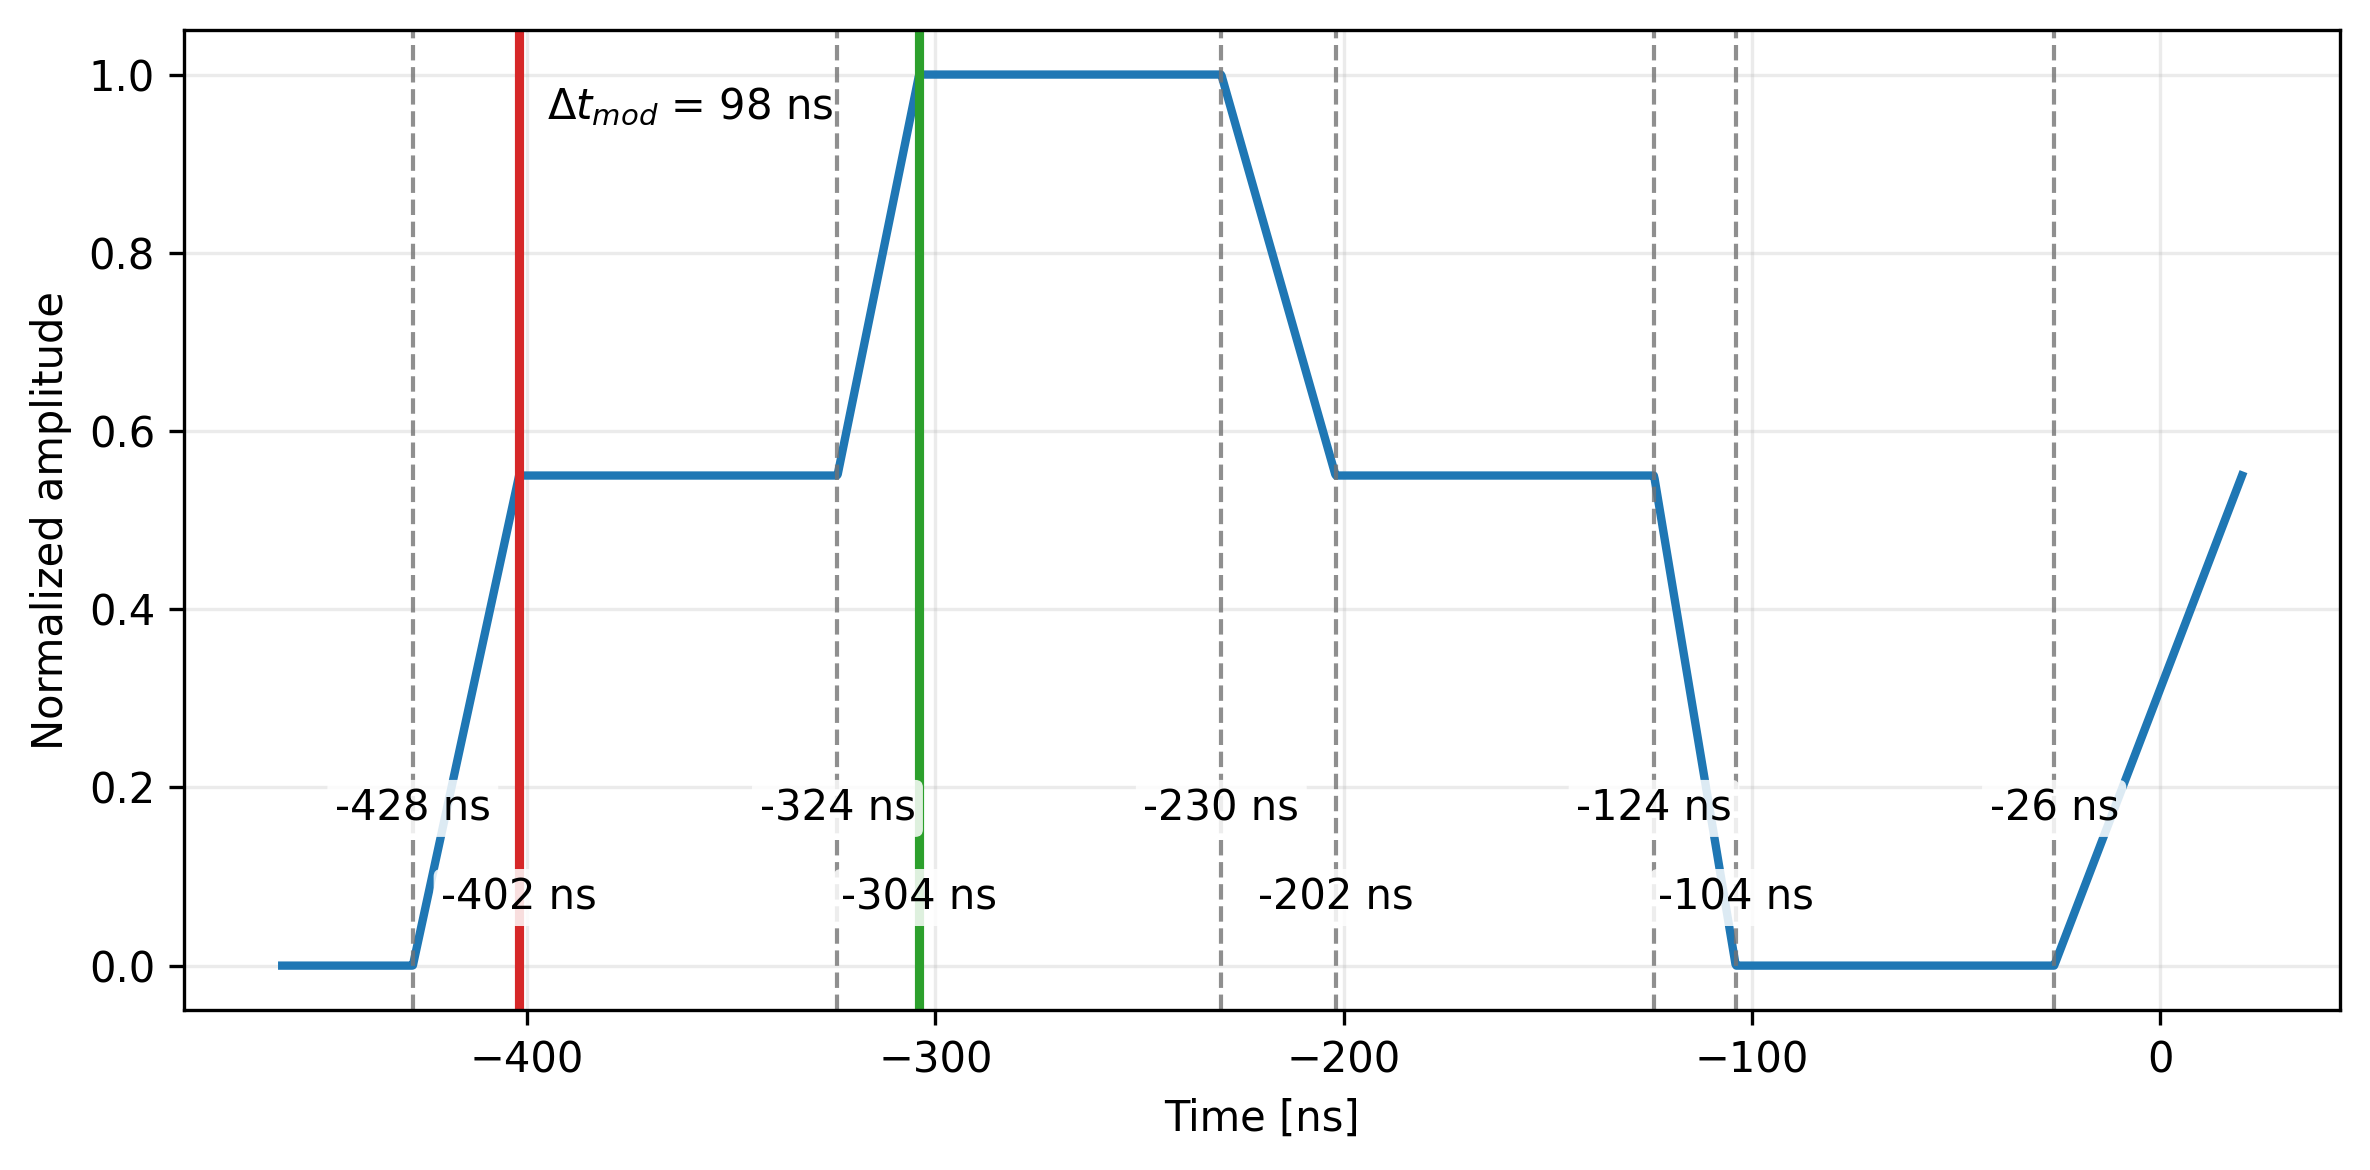

In [15]:
t_grid = np.linspace(-460, 20, 2400)
anchor_t = np.array([-460, -428, -402, -324, -304, -230, -202, -124, -104, -26, 20], dtype=float)
anchor_y = np.array([0.00, 0.00, 0.55, 0.55, 1.00, 1.00, 0.55, 0.55, 0.00, 0.00, 0.55], dtype=float)

wave = np.interp(t_grid, anchor_t, anchor_y)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_grid, wave, lw=2.0, color='C0')

# Keep timing labels horizontal below the top border, and stagger y-levels to avoid overlap.
label_levels = [0.2, 0.1]
label_spacing_ns = 30.0
last_x_for_level = [-np.inf] * len(label_levels)

for t in sorted(TIMES_NS):
    ax.axvline(t, color='0.45', lw=1.0, ls='--', alpha=0.8)

    level_idx = None
    for i, last_x in enumerate(last_x_for_level):
        if (t - last_x) >= label_spacing_ns:
            level_idx = i
            break
    if level_idx is None:
        level_idx = int(np.argmin(last_x_for_level))

    y_label = label_levels[level_idx]
    last_x_for_level[level_idx] = t
    ax.text(
        t,
        y_label,
        f"{int(t)} ns",
        rotation=0,
        va='top',
        ha='center',
        bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.85),
    )

ax.axvline(T_FIRST_PLATEAU_START_NS, color='C3', lw=2.2)
ax.axvline(T_MAX_PLATEAU_START_NS, color='C2', lw=2.2)
ax.annotate(
    r"$\Delta t_{mod}$ =" + f" {TAU_MOD_NS:.0f} ns",
    xy=((T_FIRST_PLATEAU_START_NS + T_MAX_PLATEAU_START_NS) / 2, 0.88),
    xytext=(-360, 0.95),
    ha='center',
)

ax.set_xlabel('Time [ns]')
ax.set_ylabel('Normalized amplitude')
ax.grid(alpha=0.25)
plt.tight_layout()
_nb_dir = Path('labs/02') if Path('labs/02').exists() else Path('.')
plt.savefig(_nb_dir / 'report' / 'figures' / 'reflectometry.pdf', bbox_inches='tight')
plt.show()


In [16]:
rows = []
sigma_L_sdr = float(sigma_L_lin_analytic)
sigma_L_meter = float(sigma_L_meter_unknown)

for n in range(4):
    dt_ns = TAU_MOD_NS + n * T_NS
    dt_s = dt_ns * 1e-9
    v_sdr = 2 * L_SDR_M / dt_s
    v_meter = 2 * L_METER_M / dt_s

    frac_sigma_sdr = sigma_L_sdr / abs(L_SDR_M) if abs(L_SDR_M) > 0 else np.nan
    frac_sigma_meter = sigma_L_meter / abs(L_METER_M) if abs(L_METER_M) > 0 else np.nan
    sigma_v_sdr = abs(v_sdr) * frac_sigma_sdr if np.isfinite(frac_sigma_sdr) else np.nan
    sigma_v_meter = abs(v_meter) * frac_sigma_meter if np.isfinite(frac_sigma_meter) else np.nan

    rows.append({
        'n': n,
        'delta_t_ns': dt_ns,
        'v_sdr_mps': v_sdr,
        'v_sdr_sigma_mps': sigma_v_sdr,
        'v_sdr_over_c': v_sdr / C_MPS,
        'v_sdr_over_c_sigma': sigma_v_sdr / C_MPS if np.isfinite(sigma_v_sdr) else np.nan,
        'v_meter_mps': v_meter,
        'v_meter_sigma_mps': sigma_v_meter,
        'v_meter_over_c': v_meter / C_MPS,
        'v_meter_over_c_sigma': sigma_v_meter / C_MPS if np.isfinite(sigma_v_meter) else np.nan,
    })

branches = pd.DataFrame(rows)
display(branches)

print('Velocity uncertainties above include propagated length uncertainty only (timing-pick uncertainty not included).')

assert np.isclose(TAU_MOD_NS, 98.0)
assert np.allclose(branches['delta_t_ns'].values, np.array([98.0, 498.0, 898.0, 1298.0]))
assert branches.loc[branches['n'] == 0, 'v_sdr_over_c'].iloc[0] > 1.0
assert branches.loc[branches['n'] == 0, 'v_meter_over_c'].iloc[0] > 1.0

,n,delta_t_ns,v_sdr_mps,v_sdr_sigma_mps,v_sdr_over_c,v_sdr_over_c_sigma,v_meter_mps,v_meter_sigma_mps,v_meter_over_c,v_meter_over_c_sigma
0,0,98.0,8.175291e+08,1.499226e+08,2.726984,0.500088,7.327237e+08,2.814299e+07,2.444103,0.093875
1,1,498.0,1.608792e+08,2.950285e+07,0.536635,0.098411,1.441906e+08,5.538178e+06,0.480968,0.018473
2,2,898.0,8.921810e+07,1.636127e+07,0.297600,0.054575,7.996317e+07,3.071284e+06,0.266728,0.010245
3,3,1298.0,6.172408e+07,1.131927e+07,0.205889,0.037757,5.532121e+07,2.124817e+06,0.184532,0.007088


Velocity uncertainties above include propagated length uncertainty only (timing-pick uncertainty not included).


In [17]:
def pick_branch(v_over_c_col: str) -> int:
    sub = branches[branches[v_over_c_col] < 1.0].copy()
    sub['vf_dist'] = (sub[v_over_c_col] - VF_TARGET).abs()
    return int(sub.sort_values('vf_dist').iloc[0]['n'])

n_sdr = pick_branch('v_sdr_over_c')
n_meter = pick_branch('v_meter_over_c')
sel_sdr = branches[branches['n'] == n_sdr].iloc[0]
sel_meter = branches[branches['n'] == n_meter].iloc[0]

print(f"Selected branch (SDR prior)  : n = {n_sdr}, delta_t = {sel_sdr['delta_t_ns']:.1f} ns")
print(f"Selected branch (Meter prior): n = {n_meter}, delta_t = {sel_meter['delta_t_ns']:.1f} ns")
print()
print(
    f"v_coax (SDR prior)   = {sel_sdr['v_sdr_mps']:.3e} +/- {sel_sdr['v_sdr_sigma_mps']:.3e} m/s "
    f"= {sel_sdr['v_sdr_over_c']:.4f} +/- {sel_sdr['v_sdr_over_c_sigma']:.4f} c"
)
print(
    f"v_coax (Meter prior) = {sel_meter['v_meter_mps']:.3e} +/- {sel_meter['v_meter_sigma_mps']:.3e} m/s "
    f"= {sel_meter['v_meter_over_c']:.4f} +/- {sel_meter['v_meter_over_c_sigma']:.4f} c"
)

Selected branch (SDR prior)  : n = 1, delta_t = 498.0 ns
Selected branch (Meter prior): n = 1, delta_t = 498.0 ns

v_coax (SDR prior)   = 1.609e+08 +/- 2.950e+07 m/s = 0.5366 +/- 0.0984 c
v_coax (Meter prior) = 1.442e+08 +/- 5.538e+06 m/s = 0.4810 +/- 0.0185 c


In [18]:
report_lines = [
    '### Final Reflectometry Results (Branch-resolved)',
    '',
    rf'Using $\Delta t_{{\mathrm{{mod}}}}={TAU_MOD_NS:.0f}\,\mathrm{{ns}}$ and square-wave period $T={T_NS:.0f}\,\mathrm{{ns}}$:',
    '',
    rf'- SDR prior ($L={L_SDR_M:.4f}\,\mathrm{{m}}$) selects $n={n_sdr}$, so '
    rf'$\Delta t={sel_sdr["delta_t_ns"]:.1f}\,\mathrm{{ns}}$ and '
    rf'$v_{{\mathrm{{coax}}}}={sel_sdr["v_sdr_mps"]:.6e}\pm{sel_sdr["v_sdr_sigma_mps"]:.2e}\,\mathrm{{m/s}}'
    rf'={sel_sdr["v_sdr_over_c"]:.4f}\pm{sel_sdr["v_sdr_over_c_sigma"]:.4f}c$.',
    '',
    rf'- Meter prior ($L={L_METER_M:.4f}\,\mathrm{{m}}$) selects $n={n_meter}$, so '
    rf'$\Delta t={sel_meter["delta_t_ns"]:.1f}\,\mathrm{{ns}}$ and '
    rf'$v_{{\mathrm{{coax}}}}={sel_meter["v_meter_mps"]:.6e}\pm{sel_meter["v_meter_sigma_mps"]:.2e}\,\mathrm{{m/s}}'
    rf'={sel_meter["v_meter_over_c"]:.4f}\pm{sel_meter["v_meter_over_c_sigma"]:.4f}c$.',
    '',
    'Velocity uncertainty above includes length-propagated terms only.',
]

display(Markdown('\n'.join(report_lines)))

### Final Reflectometry Results (Branch-resolved)

Using $\Delta t_{\mathrm{mod}}=98\,\mathrm{ns}$ and square-wave period $T=400\,\mathrm{ns}$:

- SDR prior ($L=40.0589\,\mathrm{m}$) selects $n=1$, so $\Delta t=498.0\,\mathrm{ns}$ and $v_{\mathrm{coax}}=1.608792e+08\pm2.95e+07\,\mathrm{m/s}=0.5366\pm0.0984c$.

- Meter prior ($L=35.9035\,\mathrm{m}$) selects $n=1$, so $\Delta t=498.0\,\mathrm{ns}$ and $v_{\mathrm{coax}}=1.441906e+08\pm5.54e+06\,\mathrm{m/s}=0.4810\pm0.0185c$.

Velocity uncertainty above includes length-propagated terms only.

In [19]:
if 'branches' in globals() and not branches.empty:
    if primary_length_source.startswith('manifest_sdr'):
        sel_primary = sel_sdr
        v_over_c = float(sel_primary['v_sdr_over_c'])
        sigma_v_over_c = float(sel_primary['v_sdr_over_c_sigma'])
        v_mps = float(sel_primary['v_sdr_mps'])
        sigma_v_mps = float(sel_primary['v_sdr_sigma_mps'])
        branch_note = 'SDR prior'
    else:
        sel_primary = sel_meter
        v_over_c = float(sel_primary['v_meter_over_c'])
        sigma_v_over_c = float(sel_primary['v_meter_over_c_sigma'])
        v_mps = float(sel_primary['v_meter_mps'])
        sigma_v_mps = float(sel_primary['v_meter_sigma_mps'])
        branch_note = 'meter prior'

    dt_ns = float(sel_primary['delta_t_ns'])
    print(f"Primary-coupled reflectometry branch ({branch_note}): n={int(sel_primary['n'])}, delta_t={dt_ns:.1f} ns")
    print(f"v_coax / c = {v_over_c:.6f} +/- {sigma_v_over_c:.6f}")
    print(f"v_coax     = {v_mps:.6e} +/- {sigma_v_mps:.2e} m/s")

    v_primary_mps = v_mps
    sigma_v_primary_mps = sigma_v_mps
    v_primary_over_c = v_over_c
    sigma_v_primary_over_c = sigma_v_over_c
else:
    print('Branch table not found; run upstream reflectometry cells first.')
    v_primary_mps = np.nan
    sigma_v_primary_mps = np.nan
    v_primary_over_c = np.nan
    sigma_v_primary_over_c = np.nan

print()
print('Downstream coupling formulas:')
print('  L_roof = v_coax * delta_t / 2')
print('  roof_loss_db = alpha_db_per_m * L_roof')
print('  V_rms = sqrt(50 * P_W),  V_pp = 2*sqrt(2)*V_rms')

Primary-coupled reflectometry branch (SDR prior): n=1, delta_t=498.0 ns
v_coax / c = 0.536635 +/- 0.098411
v_coax     = 1.608792e+08 +/- 2.95e+07 m/s

Downstream coupling formulas:
  L_roof = v_coax * delta_t / 2
  roof_loss_db = alpha_db_per_m * L_roof
  V_rms = sqrt(50 * P_W),  V_pp = 2*sqrt(2)*V_rms


## 15) Consolidated Part-1 Summary Tables

Summary tables collect fit quality, attenuation products, unknown-length estimates with uncertainties, and selection rationale for the exported primary estimate.

### Physical Plausibility Against Coax Expectations

Measured attenuation slopes are compared against RG-58-family expectations near 1420 MHz to test whether fitted values are physically credible and to flag mechanically compromised calibration points.

### Additional Consistency Diagnostics

This section records agreement/disagreement patterns across screened vs all-point fits, manifest vs bench estimates, and safety/compression constraints used for conservative bench operation.

In [20]:
# Analytic CI for manifest SDR linear L_unknown
L_ci68_lo = L_unknown_lin - sigma_L_lin_analytic
L_ci68_hi = L_unknown_lin + sigma_L_lin_analytic
L_ci68_str = f'[{L_ci68_lo:.2f}, {L_ci68_hi:.2f}]'

fit_quality = pd.DataFrame([
    {
        'Fit': 'SDR all-point',
        'n_rows': len(L_all),
        'alpha [dB/m]': f"{fit_lin_all['alpha']:.4f} +/- {fit_lin_all['sigma_alpha']:.4f}",
        'RMSE [dB]': f"{fit_lin_all['rmse']:.4f}",
        'AIC': f"{fit_lin_all['aic']:.2f}",
        'BIC': f"{fit_lin_all['bic']:.2f}",
    },
    {
        'Fit': 'SDR primary',
        'n_rows': len(L),
        'alpha [dB/m]': f"{fit_lin['alpha']:.4f} +/- {fit_lin['sigma_alpha']:.4f}",
        'RMSE [dB]': f"{fit_lin['rmse']:.4f}",
        'AIC': f"{fit_lin['aic']:.2f}",
        'BIC': f"{fit_lin['bic']:.2f}",
    },
    {
        'Fit': 'Meter all-point',
        'n_rows': len(L_all),
        'alpha [dB/m]': f"{fit_meter_all['alpha']:.4f} +/- {fit_meter_all['sigma_alpha']:.4f}",
        'RMSE [dB]': f"{fit_meter_all['rmse']:.4f}",
        'AIC': f"{fit_meter_all['aic']:.2f}",
        'BIC': f"{fit_meter_all['bic']:.2f}",
    },
    {
        'Fit': 'Meter primary',
        'n_rows': len(L),
        'alpha [dB/m]': f"{fit_meter['alpha']:.4f} +/- {fit_meter['sigma_alpha']:.4f}",
        'RMSE [dB]': f"{fit_meter['rmse']:.4f}",
        'AIC': f"{fit_meter['aic']:.2f}",
        'BIC': f"{fit_meter['bic']:.2f}",
    },
]).set_index('Fit')

estimate_summary = pd.DataFrame([
    {
        'Estimate': 'Manifest SDR',
        'L_unknown [m]': f'{L_unknown_lin:.3f}',
        'Uncertainty': L_ci68_str,
        'Notes': 'analytic +/-1sigma (covariance + obs + lead)',
    },
    {
        'Estimate': 'Manifest meter',
        'L_unknown [m]': f'{L_meter_unknown:.3f}',
        'Uncertainty': f'+/- {sigma_L_meter_unknown:.3f} m',
        'Notes': 'analytic propagation (covariance + obs + lead)',
    },
    {
        'Estimate': 'Selected primary',
        'L_unknown [m]': f'{L_unknown_primary:.3f}',
        'Uncertainty': f'+/- {L_unknown_primary_sigma:.3f} m',
        'Notes': primary_length_source,
    },
]).set_index('Estimate')

if 'L_unknown_bench_meter_m' in globals() and np.isfinite(L_unknown_bench_meter_m):
    bench_unc = 'N/A'
    if 'L_unknown_bench_meter_sigma_m' in globals() and np.isfinite(L_unknown_bench_meter_sigma_m):
        bench_unc = f'+/- {L_unknown_bench_meter_sigma_m:.3f} m (combined)'
    estimate_summary.loc['Bench analog'] = {
        'L_unknown [m]': f'{L_unknown_bench_meter_m:.3f}',
        'Uncertainty': bench_unc,
        'Notes': 'consistency cross-check',
    }

print('Fit-quality summary:')
display(fit_quality)

print('\nUnknown-length estimate summary:')
display(estimate_summary)

if 'df_bench_metrics' in globals():
    print('\nBench chain-derived metrics:')
    display(df_bench_metrics)

if 'safe_siggen_dbm_est' in globals() and np.isfinite(safe_siggen_dbm_est):
    if 'safe_siggen_sigma_db' in globals() and np.isfinite(safe_siggen_sigma_db):
        print('\nBench safety recommendation:')
        print(f'  Conservative recommended siggen setpoint for cascaded ZKL tests: <= {safe_siggen_dbm_est:.2f} +/- {safe_siggen_sigma_db:.2f} dBm')
    else:
        print('\nBench safety recommendation:')
        print(f'  Conservative recommended siggen setpoint for cascaded ZKL tests: <= {safe_siggen_dbm_est:.2f} dBm')

print(f'\nFixed lead-in length: {UNKNOWN_LEAD_LENGTH_M:.4f} +/- {SIGMA_LEAD_LENGTH_M:.4f} m ({UNKNOWN_LEAD_LENGTH_M/0.3048:.1f} ft)')
print(f'Primary unknown-length source: {primary_length_source}')

Fit-quality summary:


,n_rows,alpha [dB/m],RMSE [dB],AIC,BIC
Fit,,,,,
SDR all-point,9,1.8532 +/- 0.2607,2.5415,39.58,42.25
SDR primary,8,0.7281 +/- 0.1269,0.7953,-1.33,0.99
Meter all-point,9,1.9153 +/- 0.3608,2.4021,19.77,20.17
Meter primary,8,0.8037 +/- 0.0292,0.1242,-29.38,-29.22



Unknown-length estimate summary:


,L_unknown [m],Uncertainty,Notes
Estimate,,,
Manifest SDR,40.059,"[32.71, 47.41]",analytic +/-1sigma (covariance + obs + lead)
Manifest meter,35.903,+/- 1.379 m,analytic propagation (covariance + obs + lead)
Selected primary,40.059,+/- 7.346 m,manifest_sdr_linear
Bench analog,36.455,+/- 1.335 m (combined),consistency cross-check



Bench chain-derived metrics:


,metric,value_db,sigma_db,value_pm_sigma_db
0,baseline_loss_db,4.3,0.141421,4.300 +/- 0.141
1,unknown_incremental_loss_db,29.3,0.141421,29.300 +/- 0.141
2,roof_chain_net_gain_db,31.5,0.141421,31.500 +/- 0.141
3,kl_filter_incremental_loss_db,20.3,0.141421,20.300 +/- 0.141
4,wide_narrow_net_gain_db,12.1,0.141421,12.100 +/- 0.141
5,lab_net_vs_baseline_db,-8.2,0.141421,-8.200 +/- 0.141



Bench safety recommendation:
  Conservative recommended siggen setpoint for cascaded ZKL tests: <= 10.95 +/- 0.11 dBm

Fixed lead-in length: 3.6576 +/- 0.0001 m (12.0 ft)
Primary unknown-length source: manifest_sdr_linear


## 16) SDR Gain-Sweep Linearity and Clipping Guardrails

We analyze fixed-gain sweep data to identify the usable linear-response range and clipping thresholds that constrain reliable calibration operation.

Sweep manifest rows: 16
LO groups          : [1420.0]
Clip threshold     : 1.0e-03


,point_id,lo_mhz,sdr_gain_db,siggen_amp_dbm,manual_meter_dbm,total_power_db,i_clip_frac,q_clip_frac,clip_max_frac,is_clipped
15,16,1420.0,0.0,-19.5,-23.2,8.639950,0.000000,0.00000,0.00000,False
14,15,1420.0,0.0,-17.0,-20.5,11.106330,0.000000,0.00000,0.00000,False
13,14,1420.0,0.0,-14.5,-17.8,13.582777,0.000000,0.00000,0.00000,False
12,13,1420.0,0.0,-12.0,-15.3,16.005255,0.000000,0.00000,0.00000,False
11,12,1420.0,0.0,-9.5,-12.9,18.354068,0.000000,0.00000,0.00000,False
10,11,1420.0,0.0,-7.0,-10.4,20.931700,0.000000,0.00000,0.00000,False
9,10,1420.0,0.0,-4.5,-7.9,23.321944,0.000000,0.00000,0.00000,False
8,9,1420.0,0.0,-2.0,-5.4,25.880617,0.000000,0.00000,0.00000,False
7,8,1420.0,0.0,0.5,-2.9,28.410106,0.000000,0.00000,0.00000,False
6,7,1420.0,0.0,3.0,-0.3,31.081844,0.000000,0.00000,0.00000,False


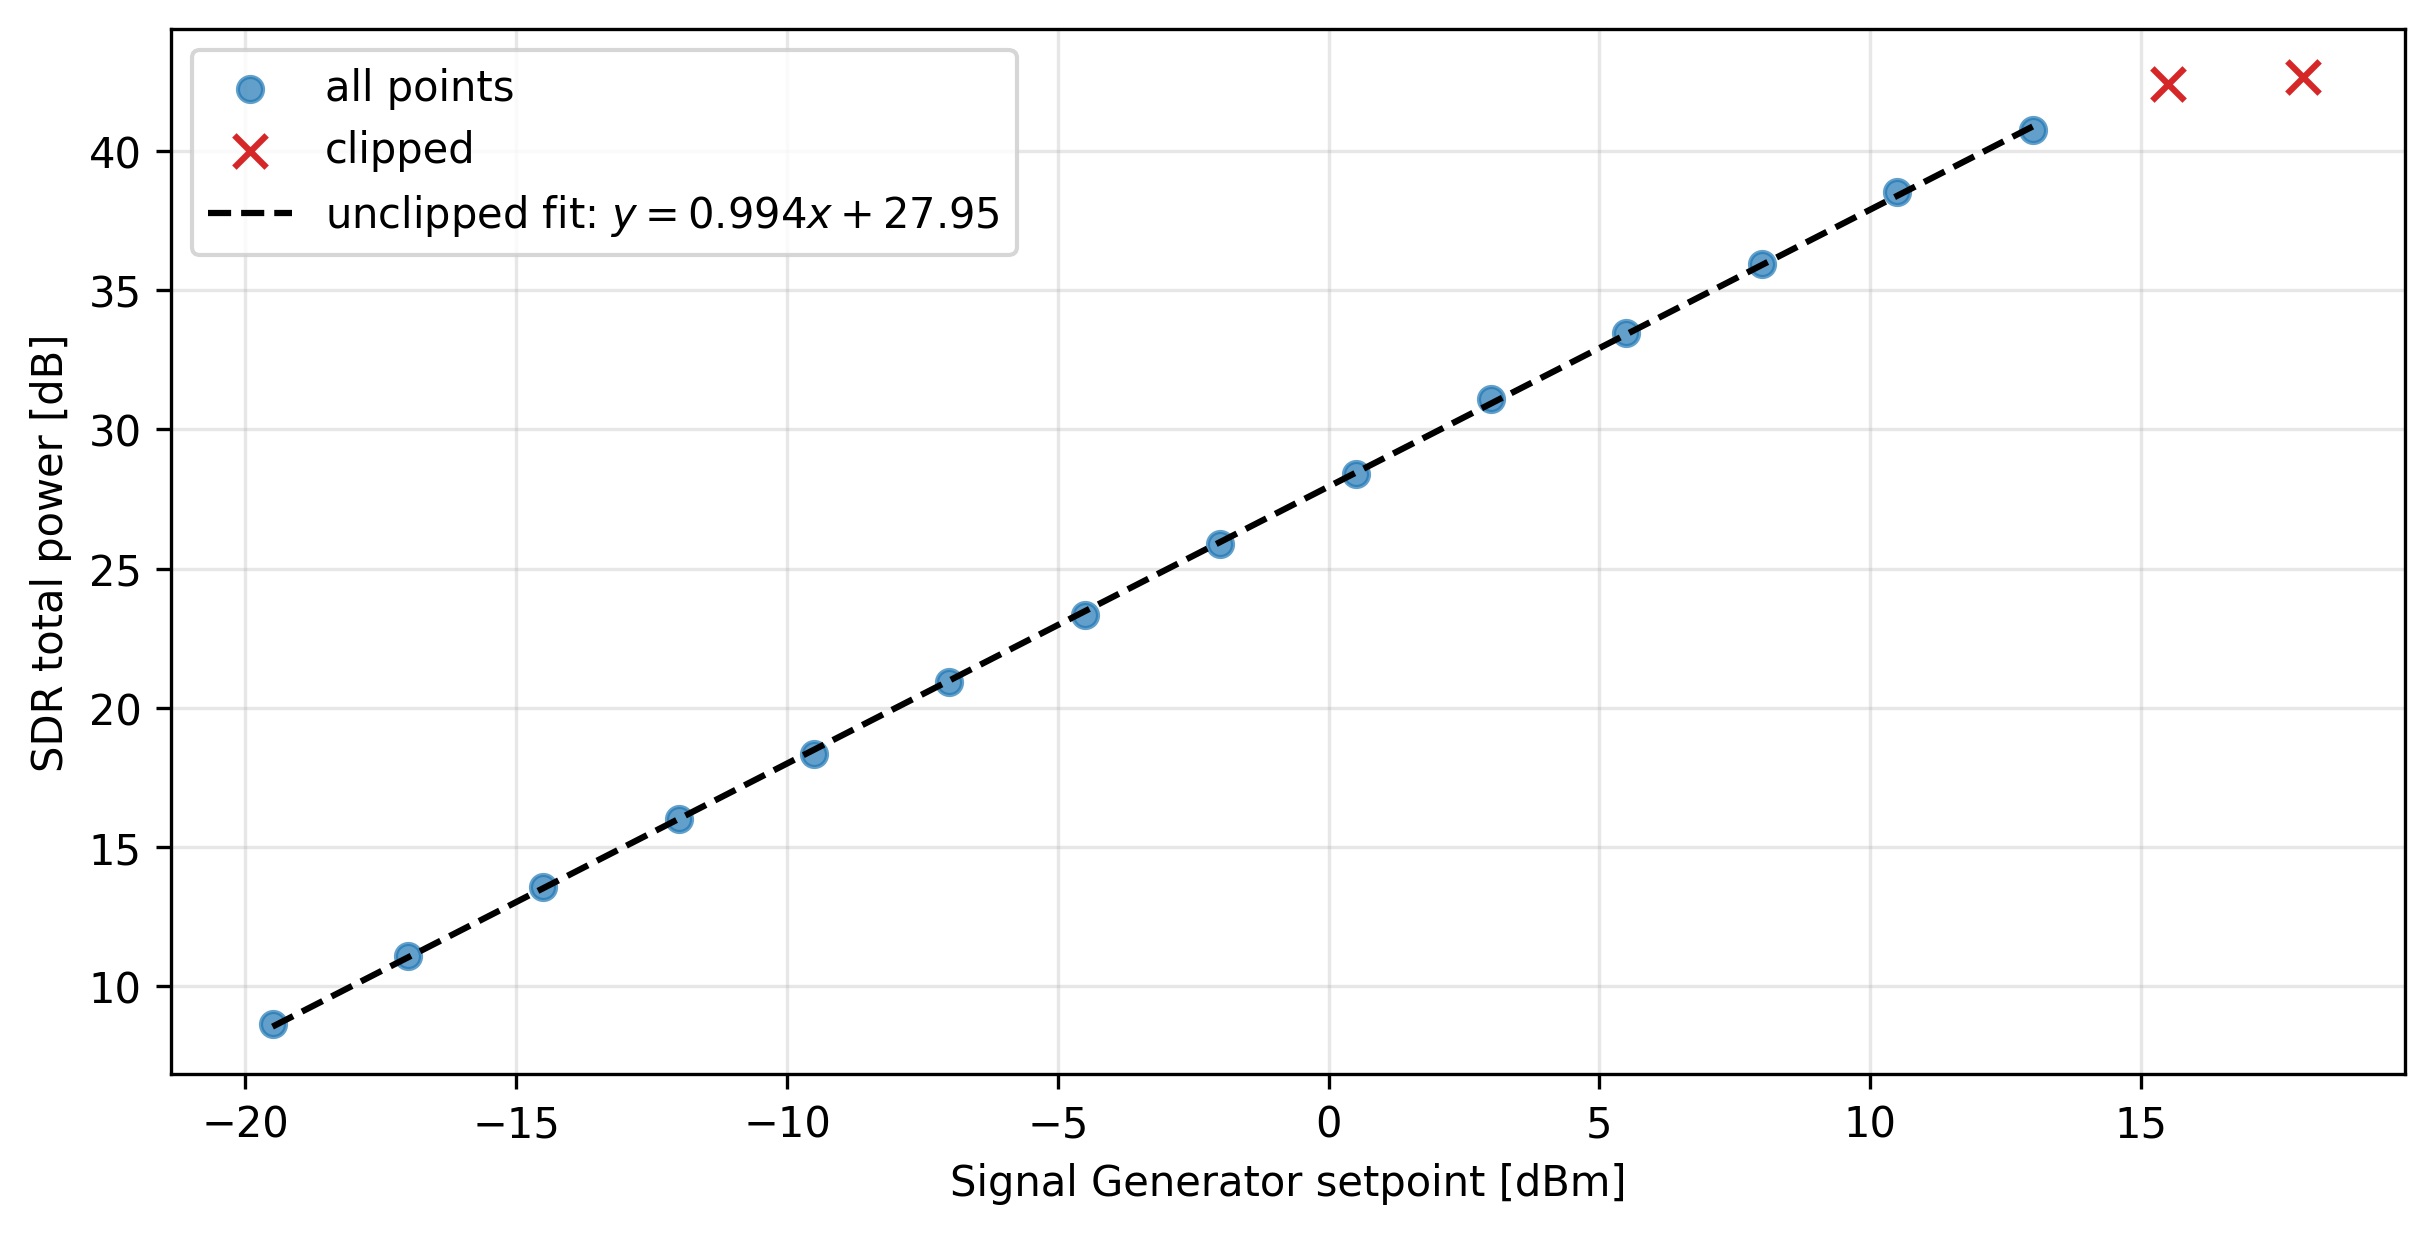

Per-LO fixed-gain sweep diagnostics (unclipped-fit based):


,lo_mhz,n_points,n_unclipped,n_clipped,highest_unclipped_setpoint_dbm,first_clipped_setpoint_dbm,slope_total_power_db_per_dbm,rmse_db,r2,meter_minus_set_mean_db,meter_minus_set_std_db
0,1420.0,16,14,2,13.0,15.5,0.994312,0.097879,0.999905,-3.39375,0.119733


Manifest-derived diagnostics above are the canonical SDR gain-sweep outputs.


In [21]:
# Load and analyze fixed-gain SDR sweep data.
SWEEP_MANIFEST = DATA_ROOT / 'sdr_gain_sweep' / 'manifest.csv'
CLIP_THRESH = 1e-3
EPS = 1e-6

if not SWEEP_MANIFEST.exists():
    raise FileNotFoundError(f'Missing sweep manifest: {SWEEP_MANIFEST}')

df_sweep = pd.read_csv(SWEEP_MANIFEST).copy()
required_cols = [
    'lo_mhz', 'siggen_amp_dbm', 'total_power_db',
    'i_clip_frac', 'q_clip_frac', 'manual_meter_dbm',
]
missing = [c for c in required_cols if c not in df_sweep.columns]
if missing:
    raise KeyError(f'Sweep manifest missing required columns: {missing}')

df_sweep['clip_max_frac'] = df_sweep[['i_clip_frac', 'q_clip_frac']].max(axis=1)
df_sweep['meter_minus_set_db'] = df_sweep['manual_meter_dbm'] - df_sweep['siggen_amp_dbm']
df_sweep['is_clipped'] = df_sweep['clip_max_frac'] >= CLIP_THRESH

print(f'Sweep manifest rows: {len(df_sweep)}')
print(f'LO groups          : {sorted(df_sweep["lo_mhz"].dropna().unique().tolist())}')
print(f'Clip threshold     : {CLIP_THRESH:.1e}')

display(
    df_sweep.sort_values(['lo_mhz', 'siggen_amp_dbm'])[
        ['point_id', 'lo_mhz', 'sdr_gain_db', 'siggen_amp_dbm', 'manual_meter_dbm',
         'total_power_db', 'i_clip_frac', 'q_clip_frac', 'clip_max_frac', 'is_clipped']
    ]
)

fit_rows = []
for lo_mhz, grp in df_sweep.groupby('lo_mhz', sort=True):
    g = grp.sort_values('siggen_amp_dbm').reset_index(drop=True)
    unclipped = g[g['is_clipped'] == False]
    clipped = g[g['is_clipped']]

    slope = np.nan
    intercept = np.nan
    rmse = np.nan
    r2 = np.nan
    if len(unclipped) >= 2:
        x = unclipped['siggen_amp_dbm'].to_numpy(dtype=float)
        y = unclipped['total_power_db'].to_numpy(dtype=float)
        slope, intercept = np.polyfit(x, y, 1)
        yhat = slope * x + intercept
        resid = y - yhat
        rmse = float(np.sqrt(np.mean(resid**2)))
        ss_res = float(np.sum(resid**2))
        ss_tot = float(np.sum((y - np.mean(y))**2))
        r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    first_clipped = float(np.min(clipped['siggen_amp_dbm'])) if len(clipped) else np.nan
    highest_unclipped = float(np.max(unclipped['siggen_amp_dbm'])) if len(unclipped) else np.nan

    fit_rows.append({
        'lo_mhz': float(lo_mhz),
        'n_points': int(len(g)),
        'n_unclipped': int(len(unclipped)),
        'n_clipped': int(len(clipped)),
        'highest_unclipped_setpoint_dbm': highest_unclipped,
        'first_clipped_setpoint_dbm': first_clipped,
        'slope_total_power_db_per_dbm': slope,
        'rmse_db': rmse,
        'r2': r2,
        'meter_minus_set_mean_db': float(np.nanmean(g['meter_minus_set_db'])),
        'meter_minus_set_std_db': float(np.nanstd(g['meter_minus_set_db'])),
    })

    if lo_mhz != 1420.0:
        continue

    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

    ax.scatter(g['siggen_amp_dbm'][:-2], g['total_power_db'][:-2], color='C0', alpha=0.7, label='all points')
    if len(clipped):
        ax.scatter(clipped['siggen_amp_dbm'], clipped['total_power_db'],
                   marker='x', s=60, color='C3', label='clipped')
    if len(unclipped) >= 2:
        xfit = np.linspace(unclipped['siggen_amp_dbm'].min(), unclipped['siggen_amp_dbm'].max(), 200)
        ax.plot(xfit, slope * xfit + intercept, '--', color='k',
                label=r'unclipped fit: $' + f'y={slope:.3f}x+{intercept:.2f}' + r'$')
    ax.set_xlabel('Signal Generator setpoint [dBm]')
    ax.set_ylabel('SDR total power [dB]')
    ax.grid(alpha=0.3)
    ax.legend()

    _nb_dir = Path('labs/02') if Path('labs/02').exists() else Path('.')
    plt.savefig(_nb_dir / 'report' / 'figures' / 'sdr_gain_response_clipping.pdf', bbox_inches='tight')
    plt.show()

fit_df = pd.DataFrame(fit_rows).sort_values('lo_mhz').reset_index(drop=True)
print('Per-LO fixed-gain sweep diagnostics (unclipped-fit based):')
display(fit_df)

print('Manifest-derived diagnostics above are the canonical SDR gain-sweep outputs.')


## 17) Part-2 / Part-3 Handoff and Scope Boundary

### Outputs consumed downstream

- attenuation and unknown-length calibration terms,
- linearity guardrails,
- FIR/summing response arrays and evaluation masks.

### Coordinate-theory boundary

`coords.tex` implementation and sky-frame transforms are intentionally handled in `analysis.ipynb` (Part 3), not in this equipment notebook.

## 18) RTL2832U FIR and Summing-Filter Response Modeling

Using `bighorn.tex` default FIR coefficients and the estimated secondary summing filter, we model response on the measured output-frequency grid and define passband support masks for robust correction.

In [22]:
# ── RTL2832U FIR coefficients (bighorn.tex default, 32-tap symmetric) ────────
h_fir = np.array([
    -54, -36, -41, -40, -32, -14,  14,  53,
    101, 156, 215, 273, 327, 372, 404, 421,
    421, 404, 372, 327, 273, 215, 156, 101,
     53,  14, -14, -32, -40, -41, -36, -54,
], dtype=float)

# Secondary summing filter estimate (bighorn.tex)
g_sum_est = np.array([-1/8, -1/4, -3/4, -1/2, -1, 8, -1, -1/2, -3/4, -1/4, -1/8], dtype=float)

# The FIR and undocumented summing stages are modeled in the RTL2832U internal
# DSP domain before decimation. We must evaluate their responses against the
# *output* spectrum axis using the internal sample-rate frequency normalization.
RTL_INTERNAL_SAMPLE_RATE_HZ = 28_800_000.0
RESPONSE_FREQ_DOMAIN = 'pre_decimation_dtft'

# ── Resolve cold_ref reference spectrum (requested: use cold_ref, not SGP) ───
COLD_REF_PATH = DATA_ROOT / 'cold_ref_combined_spectra' / 'GAL-1420_combined.npz'
if not COLD_REF_PATH.exists():
    raise FileNotFoundError(
        f'Missing cold_ref combined spectrum: {COLD_REF_PATH}. '
        'Run combination pipeline or update path policy.'
    )

spec_noise = Spectrum.load(COLD_REF_PATH)
N_FFT = int(np.asarray(spec_noise.psd).size)
SAMPLE_RATE_HZ = float(spec_noise.sample_rate)
noise_center_idx = int(spec_noise.bin_at(float(spec_noise.center_freq)))
noise_analysis_mask = np.ones(N_FFT, dtype=bool)
noise_analysis_mask[noise_center_idx] = False

# Use shifted (low->high) ordering to match Spectrum.freqs ordering
freq_offset_hz = np.asarray(spec_noise.freqs, float) - float(spec_noise.center_freq)
freq_offset_mhz = freq_offset_hz / 1e6

def power_response_on_output_axis(coeffs: np.ndarray,
                                  freq_hz: np.ndarray,
                                  internal_sample_rate_hz: float,
                                  chunk_size: int = 2048) -> np.ndarray:
    """Evaluate |H|^2 on output-spectrum frequencies with internal RTL normalization."""
    c = np.asarray(coeffs, float)
    f = np.asarray(freq_hz, float)
    n = np.arange(c.size, dtype=float)

    out = np.empty(f.size, dtype=float)
    fs = float(internal_sample_rate_hz)
    if not np.isfinite(fs) or fs <= 0:
        raise ValueError('internal_sample_rate_hz must be finite and > 0.')

    for i in range(0, f.size, chunk_size):
        fb = f[i:i + chunk_size]
        phase = np.exp(-2j * np.pi * np.outer(fb, n) / fs)
        H = phase @ c
        out[i:i + chunk_size] = np.abs(H) ** 2

    peak = float(np.nanmax(out))
    if not np.isfinite(peak) or peak <= 0:
        raise ValueError('Filter response peak is not finite/positive.')
    return out / peak

# Response models evaluated on the measured output frequency axis
P_fir_norm_shifted = power_response_on_output_axis(h_fir, freq_offset_hz, RTL_INTERNAL_SAMPLE_RATE_HZ)
P_sum_est_norm_shifted = power_response_on_output_axis(g_sum_est, freq_offset_hz, RTL_INTERNAL_SAMPLE_RATE_HZ)
P_combined_est_norm_shifted = P_fir_norm_shifted * P_sum_est_norm_shifted

# Normalize combined response for plotting/diagnostics consistency
combined_peak = float(np.nanmax(P_combined_est_norm_shifted))
if np.isfinite(combined_peak) and combined_peak > 0:
    P_combined_est_norm_shifted = P_combined_est_norm_shifted / combined_peak

# Response-defined passband mask (avoid near-zero denominator bins)
PASSBAND_DB_THRESHOLD = -6.0
passband_floor = 10 ** (PASSBAND_DB_THRESHOLD / 10.0)
passband_mask = P_fir_norm_shifted >= passband_floor

if np.sum(passband_mask) < max(64, N_FFT // 200):
    PASSBAND_DB_THRESHOLD = -10.0
    passband_floor = 10 ** (PASSBAND_DB_THRESHOLD / 10.0)
    passband_mask = P_fir_norm_shifted >= passband_floor

def _pct_ripple_db(x: np.ndarray, mask: np.ndarray, lo: float = 5.0, hi: float = 95.0) -> float:
    v = np.asarray(x, float)[mask]
    v = v[np.isfinite(v) & (v > 0)]
    if v.size < 10:
        return np.nan
    qlo, qhi = np.percentile(v, [lo, hi])
    return float(10.0 * np.log10(qhi / qlo))

print('Model-response summary (1x2 plot intentionally omitted):')
print(f'cold_ref reference path     : {COLD_REF_PATH}')
print(f'N_FFT (data-driven)         : {N_FFT}')
print(f'output sample rate          : {SAMPLE_RATE_HZ/1e6:.3f} MHz')
print(f'RTL internal sample rate    : {RTL_INTERNAL_SAMPLE_RATE_HZ/1e6:.3f} MHz')
print(f'internal/output rate ratio  : {RTL_INTERNAL_SAMPLE_RATE_HZ/SAMPLE_RATE_HZ:.3f}')
print(f'response mapping            : {RESPONSE_FREQ_DOMAIN}')
print(f'passband channels           : {int(np.sum(passband_mask))} / {N_FFT} '
      f'({100*np.mean(passband_mask):.2f}%) at threshold {PASSBAND_DB_THRESHOLD:.1f} dB')
print(f'FIR passband ripple (5-95 pct): {_pct_ripple_db(P_fir_norm_shifted, passband_mask):.3f} dB')
print(f'FIR+summing(est) ripple (5-95 pct): {_pct_ripple_db(P_combined_est_norm_shifted, passband_mask):.3f} dB')
print(f'LO center bin excluded from measured-spectrum diagnostics: index {noise_center_idx}')


Model-response summary (1x2 plot intentionally omitted):
cold_ref reference path     : ../../data/lab02/cold_ref_combined_spectra/GAL-1420_combined.npz
N_FFT (data-driven)         : 8192
output sample rate          : 2.560 MHz
RTL internal sample rate    : 28.800 MHz
internal/output rate ratio  : 11.250
response mapping            : pre_decimation_dtft
passband channels           : 8192 / 8192 (100.00%) at threshold -6.0 dB
FIR passband ripple (5-95 pct): 3.169 dB
FIR+summing(est) ripple (5-95 pct): 1.054 dB
LO center bin excluded from measured-spectrum diagnostics: index 4096


## 19) White-Noise Verification Using `cold_ref`

We use combined cold-reference spectra as a broadband proxy and evaluate whether model-based correction flattens the passband over response-supported channels.

In [23]:
# ── Cold-ref white-noise proxy verification ───────────────────────────────────
noise_psd_shifted = np.array(spec_noise.psd_values(mask_dc=True), float, copy=True)  # low->high ordering

# Robust Savitzky-Golay baseline for narrow-band outlier mask
from scipy.signal import savgol_filter

def _fill_nan_linear(x: np.ndarray) -> np.ndarray:
    arr = np.asarray(x, float)
    finite = np.isfinite(arr)
    if finite.sum() < 2:
        raise ValueError('Need at least two finite channels to interpolate across the LO bin.')
    idx = np.arange(arr.size, dtype=float)
    out = arr.copy()
    out[~finite] = np.interp(idx[~finite], idx[finite], arr[finite])
    return out

window = min(257, N_FFT - (1 - N_FFT % 2))
if window < 7:
    window = 7 if N_FFT >= 7 else (N_FFT // 2) * 2 + 1

baseline_seed = _fill_nan_linear(noise_psd_shifted)
baseline = np.array(spec_noise.mask_dc_bin(savgol_filter(baseline_seed, window_length=window, polyorder=3, mode='interp')), float, copy=True)
resid = noise_psd_shifted - baseline
finite_resid = resid[np.isfinite(resid)]
med_resid = float(np.median(finite_resid))
mad = float(np.median(np.abs(finite_resid - med_resid)))
scale = 1.4826 * mad if mad > 0 else float(np.nanstd(finite_resid))

if scale <= 0:
    rfi_mask = noise_analysis_mask.copy()
else:
    rfi_mask = noise_analysis_mask & (np.abs(resid - med_resid) < 3.0 * scale)

combined_mask = passband_mask & noise_analysis_mask & rfi_mask
if np.sum(combined_mask) < 64:
    combined_mask = passband_mask & noise_analysis_mask

response_floor = 10 ** (-20.0 / 10.0)

def _normalise_in_mask(x: np.ndarray, mask: np.ndarray) -> np.ndarray:
    v = np.asarray(x, float)[mask]
    v = v[np.isfinite(v) & (v > 0)]
    if v.size == 0:
        return np.asarray(x, float)
    med = float(np.median(v))
    return np.asarray(x, float) / med

def _ripple_db(x: np.ndarray, mask: np.ndarray, lo: float = 5.0, hi: float = 95.0) -> float:
    v = np.asarray(x, float)[mask]
    v = v[np.isfinite(v) & (v > 0)]
    if v.size < 10:
        return np.nan
    qlo, qhi = np.percentile(v, [lo, hi])
    return float(10.0 * np.log10(qhi / qlo))

def _frac_std(x: np.ndarray, mask: np.ndarray) -> float:
    v = np.asarray(x, float)[mask]
    v = v[np.isfinite(v) & (v > 0)]
    if v.size < 10:
        return np.nan
    vn = v / np.median(v)
    return float(np.std(vn - 1.0))

noise_norm = _normalise_in_mask(noise_psd_shifted, combined_mask)
after_fir = noise_norm / np.clip(P_fir_norm_shifted, response_floor, None)
after_both_est = noise_norm / np.clip(P_combined_est_norm_shifted, response_floor, None)

after_fir_n = _normalise_in_mask(after_fir, combined_mask)
after_both_est_n = _normalise_in_mask(after_both_est, combined_mask)

print('Cold-ref whitening summary (1x3 plot intentionally omitted):')
print(f'RFI mask kept channels            : {int(np.sum(rfi_mask))} / {N_FFT} ({100*np.mean(rfi_mask):.2f}%)')
print(f'Combined eval mask channels       : {int(np.sum(combined_mask))} / {N_FFT} ({100*np.mean(combined_mask):.2f}%)')
print(f'Ripple raw (5-95 pct, eval mask)  : {_ripple_db(noise_norm, combined_mask):.3f} dB')
print(f'Ripple after FIR                   : {_ripple_db(after_fir_n, combined_mask):.3f} dB')
print(f'Ripple after FIR+sum(est)          : {_ripple_db(after_both_est_n, combined_mask):.3f} dB')
print(f'Frac std raw / FIR / FIR+sum(est) : '
      f'{_frac_std(noise_norm, combined_mask):.4f} / '
      f'{_frac_std(after_fir_n, combined_mask):.4f} / '
      f'{_frac_std(after_both_est_n, combined_mask):.4f}')


Cold-ref whitening summary (1x3 plot intentionally omitted):
RFI mask kept channels            : 8089 / 8192 (98.74%)
Combined eval mask channels       : 8089 / 8192 (98.74%)
Ripple raw (5-95 pct, eval mask)  : 6.254 dB
Ripple after FIR                   : 3.374 dB
Ripple after FIR+sum(est)          : 6.004 dB
Frac std raw / FIR / FIR+sum(est) : 0.2665 / 0.1731 / 0.2781


## 20) Constrained Summing-Filter Optimization

The residual passband ripple is reduced by fitting a symmetric 11-tap summing filter (`[a,b,c,d,e,f,e,d,c,b,a]`) to minimize variance of corrected broadband power in the evaluation mask.

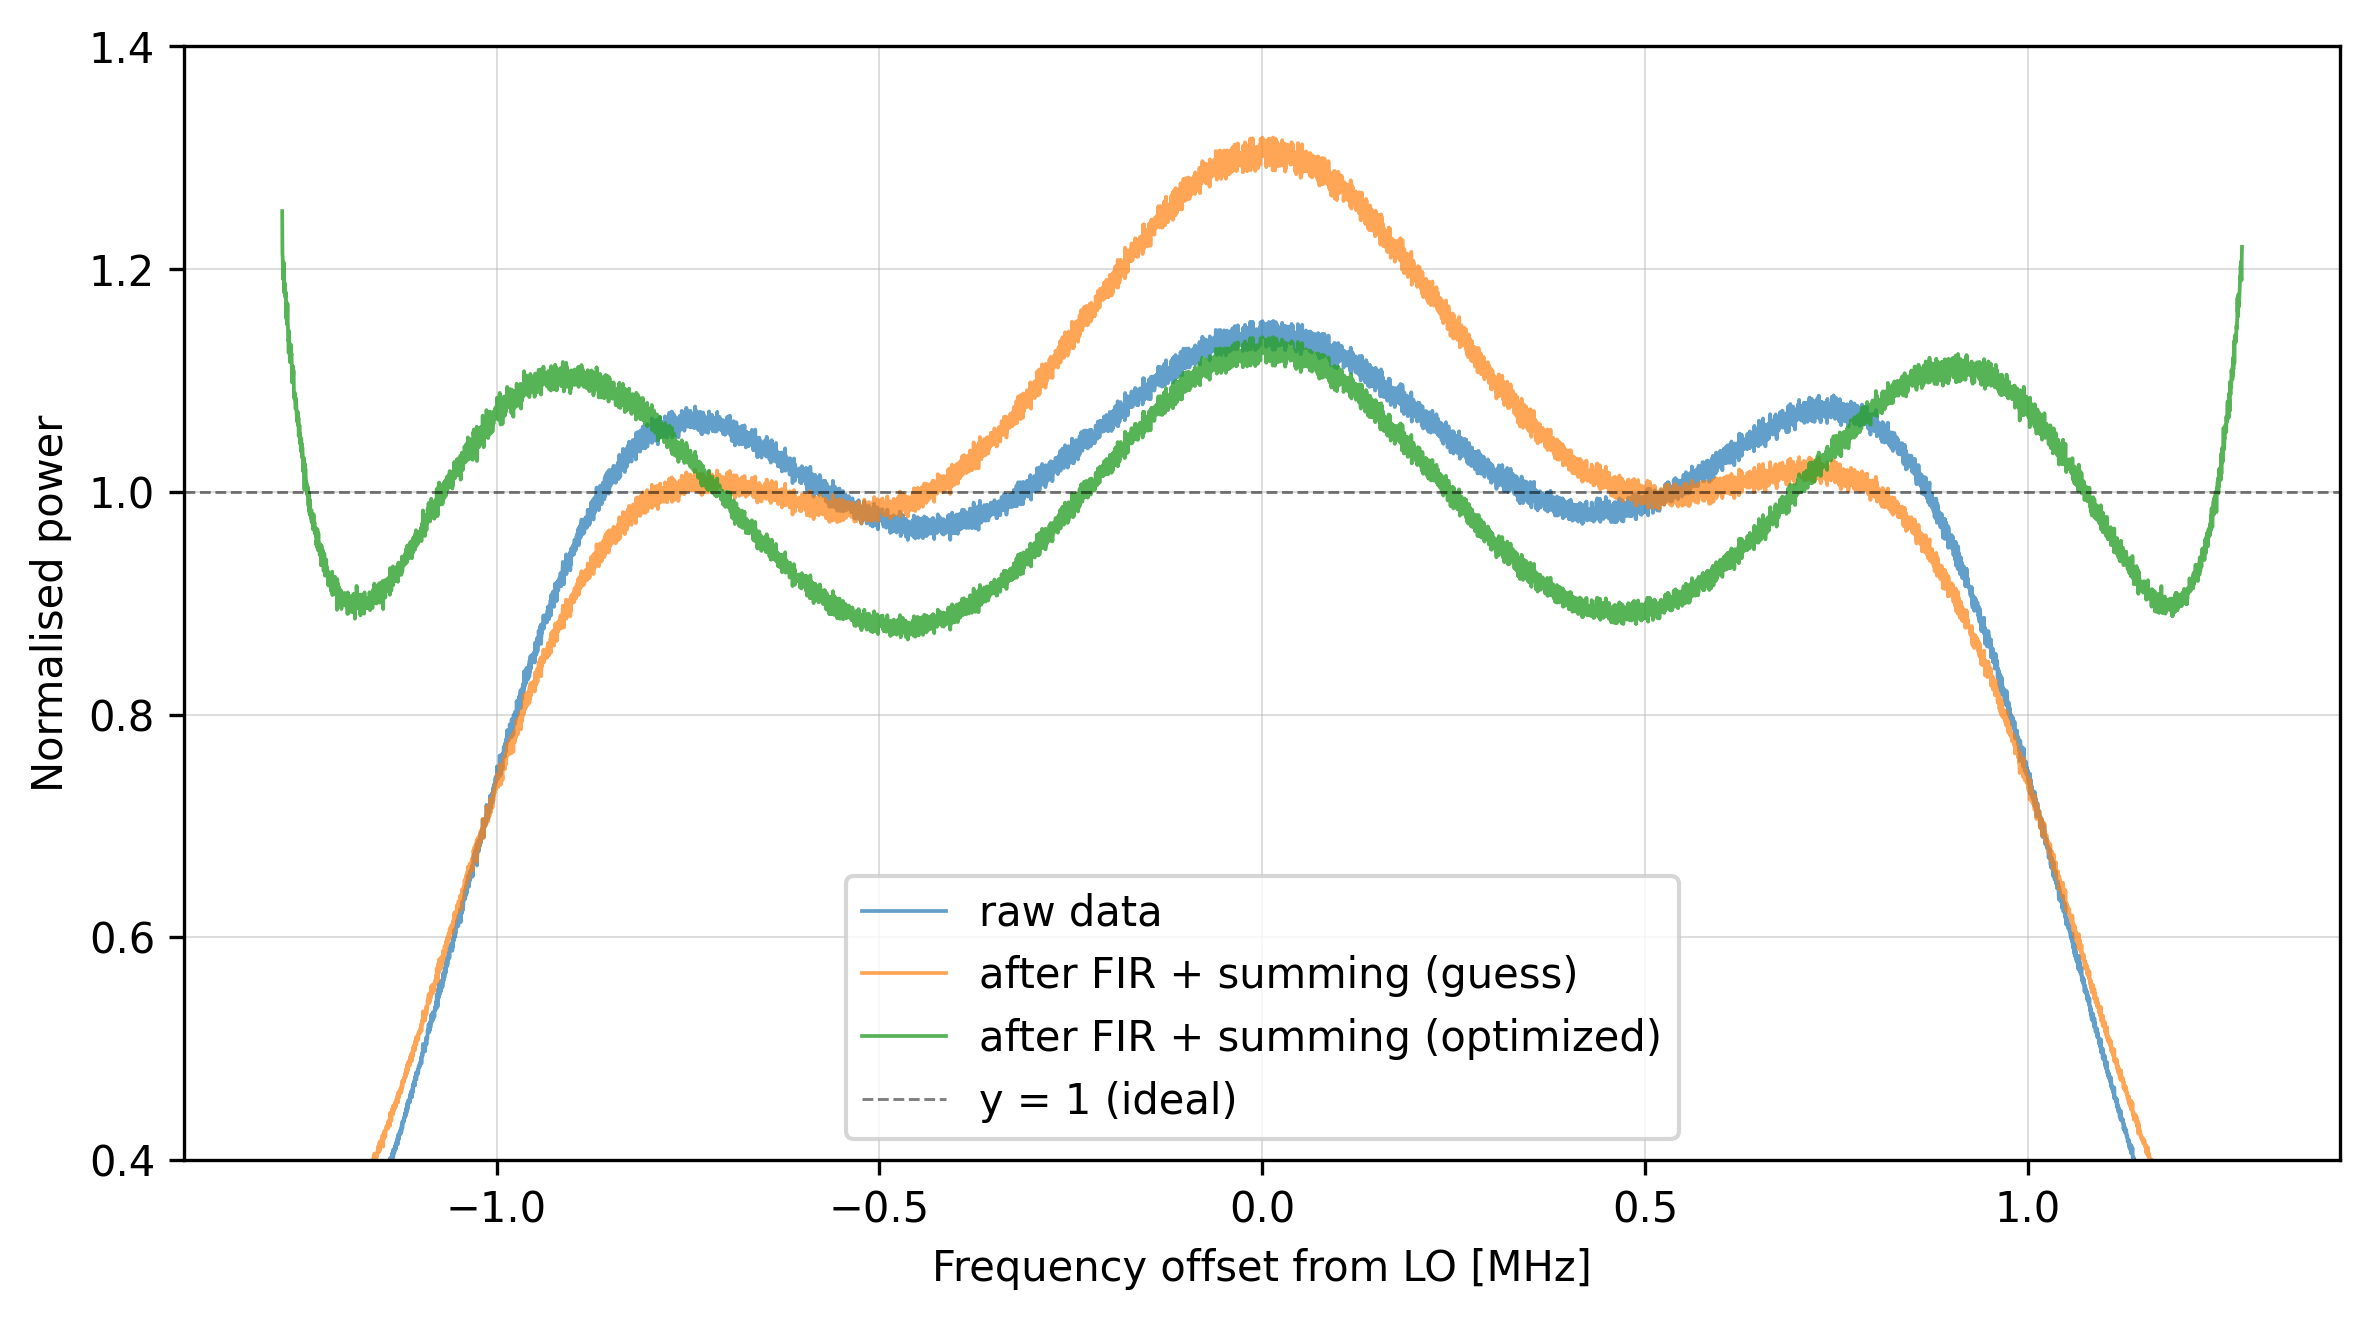

Optimization converged: True  (message: Optimization terminated successfully.)
Initial objective variance : 7.732832e-02
Optimized objective variance: 6.652888e-03
Ripple after init summing   : 6.004 dB
Ripple after opt summing    : 1.001 dB
Ripple improvement          : +5.003 dB
Frac-std after opt          : 0.08157

Optimized symmetric 11-tap summing coefficients:
[-1.64374, -4.323269, 5.380175, 18.958588, -19.097793, 2.283657, -19.097793, 18.958588, 5.380175, -4.323269, -1.64374]

Full-coefficients array (rounded to 8 sig figs):
  g[ 0] = -1.64373976
  g[ 1] = -4.32326949
  g[ 2] = +5.38017474
  g[ 3] = +18.95858759
  g[ 4] = -19.09779254
  g[ 5] = +2.28365741
  g[ 6] = -19.09779254
  g[ 7] = +18.95858759
  g[ 8] = +5.38017474
  g[ 9] = -4.32326949
  g[10] = -1.64373976


In [24]:
from scipy.optimize import minimize

# Symmetric 11-tap parameterisation: [a,b,c,d,e,f,e,d,c,b,a]
def make_symmetric_sum_filter(theta6: np.ndarray) -> np.ndarray:
    a, b, c, d, e, f = np.asarray(theta6, float)
    return np.array([a, b, c, d, e, f, e, d, c, b, a], dtype=float)


def summing_response_norm_shifted(g_coeffs: np.ndarray) -> np.ndarray:
    return power_response_on_output_axis(
        np.asarray(g_coeffs, float),
        freq_offset_hz,
        RTL_INTERNAL_SAMPLE_RATE_HZ,
    )


def corrected_with_summing(P_sum_norm_shifted: np.ndarray) -> np.ndarray:
    return noise_norm / np.clip(P_fir_norm_shifted * P_sum_norm_shifted, response_floor, None)


def objective(theta6: np.ndarray) -> float:
    g = make_symmetric_sum_filter(theta6)
    P_sum = summing_response_norm_shifted(g)
    corr = corrected_with_summing(P_sum)

    x = np.asarray(corr, float)[combined_mask]
    x = x[np.isfinite(x) & (x > 0)]
    if x.size < 64:
        return 1e10

    x = x / np.median(x)
    return float(np.var(x))


theta_init = np.array([-1/8, -1/4, -3/4, -1/2, -1, 8], dtype=float)
g_init = make_symmetric_sum_filter(theta_init)
P_sum_init_norm_shifted = summing_response_norm_shifted(g_init)

after_init = corrected_with_summing(P_sum_init_norm_shifted)
after_init_n = _normalise_in_mask(after_init, combined_mask)

result = minimize(
    objective,
    theta_init,
    method='Nelder-Mead',
    options={'maxiter': 60_000, 'xatol': 1e-9, 'fatol': 1e-12, 'adaptive': True},
)

theta_opt = np.asarray(result.x, float)
g_opt = make_symmetric_sum_filter(theta_opt)
P_sum_opt_norm_shifted = summing_response_norm_shifted(g_opt)

after_opt = corrected_with_summing(P_sum_opt_norm_shifted)
after_opt_n = _normalise_in_mask(after_opt, combined_mask)

ripple_init = _ripple_db(after_init_n, combined_mask)
ripple_opt = _ripple_db(after_opt_n, combined_mask)

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
ax.plot(freq_offset_mhz[combined_mask], noise_norm[combined_mask],
        lw=0.9, color='C0', alpha=0.7, label='raw data')
ax.plot(freq_offset_mhz[combined_mask], after_init_n[combined_mask],
        lw=0.9, color='C1', alpha=0.7, label='after FIR + summing (guess)')
ax.plot(freq_offset_mhz[combined_mask], after_opt_n[combined_mask],
        lw=0.9, color='C2', alpha=0.8, label='after FIR + summing (optimized)')
ax.axhline(1.0, color='k', lw=0.7, ls='--', alpha=0.5, label='y = 1 (ideal)')
ax.set_xlabel('Frequency offset from LO [MHz]')
ax.set_ylabel('Normalised power')
ax.legend()
ax.grid(True, lw=0.4, alpha=0.5)
ax.set_ylim(0.4, 1.4)
fig.tight_layout()
_nb_dir = Path('labs/02') if Path('labs/02').exists() else Path('.')
plt.savefig(_nb_dir / 'report' / 'figures' / 'sdr_fir_summing_correction.pdf', bbox_inches='tight')
plt.show()

print(f'Optimization converged: {result.success}  (message: {result.message})')
print(f'Initial objective variance : {objective(theta_init):.6e}')
print(f'Optimized objective variance: {objective(theta_opt):.6e}')
print(f'Ripple after init summing   : {ripple_init:.3f} dB')
print(f'Ripple after opt summing    : {ripple_opt:.3f} dB')
if np.isfinite(ripple_init) and np.isfinite(ripple_opt) and ripple_init != 0:
    print(f'Ripple improvement          : {(ripple_init - ripple_opt):+.3f} dB')
print(f'Frac-std after opt          : {_frac_std(after_opt_n, combined_mask):.5f}')

print('\nOptimized symmetric 11-tap summing coefficients:')
g_list = np.round(g_opt, 6).tolist()
print(g_list)
print(f'\nFull-coefficients array (rounded to 8 sig figs):')
for i, v in enumerate(g_opt):
    print(f'  g[{i:2d}] = {v:+.8f}')


## 21) Export Contract (Hard Cutover to v2)

This notebook exports `equipment_calibration_results_v2.npz` under `labs/02/cache/` with `schema_version = "2.0.0"`.

The v2 artifact is grouped by semantic namespace (`model.*`, `length.*`, `response.*`, `linearity.*`, `provenance.*`, `trace.*`) and is intended to be the sole downstream contract for Part 2.

In [25]:
from pathlib import Path
from datetime import datetime, timezone
import subprocess

import numpy as np
import pandas as pd

def _pick_first_global(names, default=np.nan):
    for name in names:
        if name in globals():
            return globals()[name]
    return default

def _git_commit_short() -> str:
    try:
        return subprocess.check_output(['git', 'rev-parse', '--short', 'HEAD'], text=True).strip()
    except Exception:
        return 'unknown'

# --- model terms ---
alpha_db_per_m = float(_pick_first_global(['fit_lin'], {'alpha': np.nan})['alpha'])
sigma_alpha_db_per_m = float(_pick_first_global(['fit_lin'], {'sigma_alpha': np.nan})['sigma_alpha'])
model_fit_method = 'shared_linear_screened' if bool(_pick_first_global(['screening_applied'], False)) else 'shared_linear_all_points'

# --- length terms ---
unknown_cable_length_m = float(_pick_first_global(['L_unknown_primary', 'L_unknown_lin'], np.nan))
unknown_cable_length_sigma_m = float(_pick_first_global(['L_unknown_primary_sigma', 'sigma_L_lin_analytic'], np.nan))
unknown_length_method = str(_pick_first_global(['primary_length_source'], 'unknown'))
lead_subtracted_m = float(_pick_first_global(['UNKNOWN_LEAD_LENGTH_M'], np.nan))

# --- instrument resolution terms ---
ruler_division_m = float(_pick_first_global(['METER_RULE_DIVISION_M'], np.nan))
ruler_sigma_read_m = float(_pick_first_global(['SIGMA_LENGTH_READ_M'], np.nan))
power_meter_division_dbm = float(_pick_first_global(['POWER_METER_DIVISION_DB'], np.nan))
power_meter_sigma_read_dbm = float(_pick_first_global(['POWER_METER_UNCERTAINTY_DB'], np.nan))

# --- linearity terms from SDR gain sweep ---
fit_df_local = _pick_first_global(['fit_df'], None)
if isinstance(fit_df_local, pd.DataFrame) and not fit_df_local.empty:
    fit_df_sorted = fit_df_local.sort_values('lo_mhz').reset_index(drop=True)
    highest_unclipped_setpoint_dbm = float(np.nanmin(fit_df_sorted['highest_unclipped_setpoint_dbm']))
    first_clipped_setpoint_dbm = float(np.nanmin(fit_df_sorted['first_clipped_setpoint_dbm']))
    sweep_rmse_db = fit_df_sorted['rmse_db'].to_numpy(dtype=float)
    sweep_lo_mhz = fit_df_sorted['lo_mhz'].to_numpy(dtype=float)
    clip_threshold = float(_pick_first_global(['CLIP_THRESH'], np.nan))
else:
    highest_unclipped_setpoint_dbm = np.nan
    first_clipped_setpoint_dbm = np.nan
    sweep_rmse_db = np.array([], dtype=float)
    sweep_lo_mhz = np.array([], dtype=float)
    clip_threshold = np.nan

# --- reflectometry uncertainty terms ---
v_primary_mps = float(_pick_first_global(['v_primary_mps'], np.nan))
sigma_v_primary_mps = float(_pick_first_global(['sigma_v_primary_mps'], np.nan))
v_primary_over_c = float(_pick_first_global(['v_primary_over_c'], np.nan))
sigma_v_primary_over_c = float(_pick_first_global(['sigma_v_primary_over_c'], np.nan))

# --- response terms ---
freq_offset_mhz = np.asarray(_pick_first_global(['freq_offset_mhz'], np.array([], dtype=float)), dtype=float)
fir_response_norm = np.asarray(_pick_first_global(['P_fir_norm_shifted'], np.array([], dtype=float)), dtype=float)
sum_response = _pick_first_global(['P_sum_opt_norm_shifted'], None)
if sum_response is None:
    sum_response = _pick_first_global(['P_sum_est_norm_shifted'], np.array([], dtype=float))
sum_response_norm = np.asarray(sum_response, dtype=float)

combined_response_norm = np.asarray(fir_response_norm, float) * np.asarray(sum_response_norm, float)
if combined_response_norm.size:
    peak = float(np.nanmax(combined_response_norm))
    if np.isfinite(peak) and peak > 0:
        combined_response_norm = combined_response_norm / peak

passband_mask = np.asarray(_pick_first_global(['passband_mask'], np.array([], dtype=bool)), dtype=bool)
eval_mask = np.asarray(_pick_first_global(['combined_mask'], passband_mask), dtype=bool)

response_floor = float(_pick_first_global(['response_floor'], np.nan))
if not np.isfinite(response_floor) or response_floor <= 0:
    finite_eval = np.isfinite(combined_response_norm) & np.asarray(eval_mask, bool)
    if np.any(finite_eval):
        response_floor = float(np.nanmin(combined_response_norm[finite_eval]))
if not np.isfinite(response_floor) or response_floor <= 0:
    response_floor = 10 ** (-20.0 / 10.0)

if freq_offset_mhz.size and fir_response_norm.size and fir_response_norm.size != freq_offset_mhz.size:
    raise ValueError('fir_response_norm and freq_offset_mhz size mismatch')
if sum_response_norm.size and freq_offset_mhz.size and sum_response_norm.size != freq_offset_mhz.size:
    raise ValueError('sum_response_norm and freq_offset_mhz size mismatch')
if combined_response_norm.size and freq_offset_mhz.size and combined_response_norm.size != freq_offset_mhz.size:
    raise ValueError('combined_response_norm and freq_offset_mhz size mismatch')
if passband_mask.size and freq_offset_mhz.size and passband_mask.size != freq_offset_mhz.size:
    raise ValueError('passband_mask and freq_offset_mhz size mismatch')
if eval_mask.size and freq_offset_mhz.size and eval_mask.size != freq_offset_mhz.size:
    raise ValueError('eval_mask and freq_offset_mhz size mismatch')

# --- provenance + traceability ---
created_utc = datetime.now(timezone.utc).isoformat()
source_notebook = 'labs/02/equipment_calibration.ipynb'
git_commit = _git_commit_short()
requirement_ids = np.array([
    'R-SC-001', 'R-SC-002', 'R-SC-003', 'R-SC-004', 'R-SC-005', 'R-SC-006', 'R-SC-007',
    'R-CAL-001', 'R-CAL-002', 'R-COORD-001'
], dtype='U32')

out_path = CACHE_DIR / 'equipment_calibration_results_v2.npz'
artifact = {
    'schema_version': np.str_('2.0.0'),
    'model.alpha_db_per_m': np.float64(alpha_db_per_m),
    'model.sigma_alpha_db_per_m': np.float64(sigma_alpha_db_per_m),
    'model.fit_method': np.str_(model_fit_method),
    'length.unknown_m': np.float64(unknown_cable_length_m),
    'length.sigma_unknown_m': np.float64(unknown_cable_length_sigma_m),
    'length.method': np.str_(unknown_length_method),
    'length.lead_subtracted_m': np.float64(lead_subtracted_m),
    'instrument.ruler_division_m': np.float64(ruler_division_m),
    'instrument.ruler_sigma_read_m': np.float64(ruler_sigma_read_m),
    'instrument.power_meter_division_dbm': np.float64(power_meter_division_dbm),
    'instrument.power_meter_sigma_read_dbm': np.float64(power_meter_sigma_read_dbm),
    'reflectometry.v_primary_mps': np.float64(v_primary_mps),
    'reflectometry.sigma_v_primary_mps': np.float64(sigma_v_primary_mps),
    'reflectometry.v_primary_over_c': np.float64(v_primary_over_c),
    'reflectometry.sigma_v_primary_over_c': np.float64(sigma_v_primary_over_c),
    'response.freq_offset_mhz': np.asarray(freq_offset_mhz, dtype=np.float64),
    'response.fir_power_norm': np.asarray(fir_response_norm, dtype=np.float64),
    'response.sum_power_norm': np.asarray(sum_response_norm, dtype=np.float64),
    'response.combined_power_norm': np.asarray(combined_response_norm, dtype=np.float64),
    'response.passband_mask': np.asarray(passband_mask, dtype=bool),
    'response.eval_mask': np.asarray(eval_mask, dtype=bool),
    'response.floor': np.float64(response_floor),
    'linearity.highest_unclipped_setpoint_dbm': np.float64(highest_unclipped_setpoint_dbm),
    'linearity.first_clipped_setpoint_dbm': np.float64(first_clipped_setpoint_dbm),
    'linearity.lo_mhz': np.asarray(sweep_lo_mhz, dtype=np.float64),
    'linearity.sweep_rmse_db': np.asarray(sweep_rmse_db, dtype=np.float64),
    'linearity.clip_threshold': np.float64(clip_threshold),
    'provenance.source_notebook': np.str_(source_notebook),
    'provenance.created_utc': np.str_(created_utc),
    'provenance.git_commit': np.str_(git_commit),
    'trace.requirement_ids': requirement_ids,
}
np.savez(str(out_path), **artifact)

print(f'Wrote equipment calibration v2 artifact: {out_path}')
print(f"  schema_version                 : {artifact['schema_version']}")
print(f"  model.alpha_db_per_m           : {alpha_db_per_m:.6f} +/- {sigma_alpha_db_per_m:.6f}")
print(f"  length.unknown_m               : {unknown_cable_length_m:.6f} +/- {unknown_cable_length_sigma_m:.6f}")
print(f"  reflectometry.v_primary_mps    : {v_primary_mps:.6e} +/- {sigma_v_primary_mps:.2e}")
print(f"  linearity.highest_unclipped... : {highest_unclipped_setpoint_dbm}")
print(f"  linearity.sweep_rmse_db        : {sweep_rmse_db.tolist()}")
print(f"  response.floor                 : {response_floor:.6e}")
print(f'  response grid length           : {freq_offset_mhz.size}')
print(f'  provenance.git_commit          : {git_commit}')

Wrote equipment calibration v2 artifact: cache/equipment_calibration_results_v2.npz
  schema_version                 : 2.0.0
  model.alpha_db_per_m           : 0.728112 +/- 0.126931
  length.unknown_m               : 40.058927 +/- 7.346208
  reflectometry.v_primary_mps    : 1.608792e+08 +/- 2.95e+07
  linearity.highest_unclipped... : 13.0
  linearity.sweep_rmse_db        : [0.09787936407205225]
  response.floor                 : 1.000000e-02
  response grid length           : 8192
  provenance.git_commit          : 2b131da
